#Ciência de Dados: Análise de Dados Aplicada
##Trabalho final


###Aluno: Alan Nakamura Kageyama
###Ra: 2482053

##Bibliotecas

In [2]:
import urllib.request
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

import xgboost as xgb

import duckdb

##Fonte Principal: NYC Citywide Annualized Calendar Sales Update

###Pergunta
De que maneira a flutuação dos indicadores macroeconômicos e a densidade de criminalidade local influenciam a variação dos preços imobiliários nos diferentes distritos de Nova York?

###Hipoteses
Hipótese 1: Incidência de crimes afetam os preços dos imóveis, sendo mais impactante em imóveis residenciais do que em comerciais.

Hipótese 2: A taxa de juros hipotecária é um preditor negativo do volume e preço dos imóveis.

Hipótese 3: Distritos com alta demanda são mais resistentes ao impacto tanto do crime quanto da variação de juros.

Os dados dos anos de 2018-2021 são muito complicados por causa da pandemia. Por conta disso, decidi pegar os anos de 2022-2025.

###Carregando os dados

In [3]:
print("Iniciando o download do dataset Principal. Isso pode levar alguns segundos!")

filename = "nyc_sales_raw.csv"
url = "https://data.cityofnewyork.us/api/views/w2pb-icbu/rows.csv?accessType=DOWNLOAD"

if not os.path.exists(filename):
    try:
        urllib.request.urlretrieve(url, filename)
        tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
        print(f"{filename} baixado com sucesso! Tamanho: {tamanho_mb:.2f} MB")
    except Exception as e:
        print(f"Erro ao baixar {filename}: {e}")
else:
    tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"O arquivo {filename} já existe no diretório. Tamanho: {tamanho_mb:.2f} MB.")

print("Download foi finalizado!")

Iniciando o download do dataset Principal. Isso pode levar alguns segundos!
nyc_sales_raw.csv baixado com sucesso! Tamanho: 148.58 MB
Download foi finalizado!


###Analisando os dados

In [4]:
df_nyc_sales = pd.read_csv('nyc_sales_raw.csv')
display(df_nyc_sales.head())

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AS OF FINAL ROLL,BLOCK,LOT,EASE-MENT,BUILDING CLASS AS OF FINAL ROLL,ADDRESS,APARTMENT NUMBER,...,SALE PRICE,SALE DATE,Latitude,Longitude,Community Board,Council District,BIN,BBL,Census Tract 2020,Neighborhood Tabulation Area (NTA) (2020)
0,1,CHINATOWN,47 CONDO NON-BUSINESS STORAGE,4,172,1490,NaN,RS,"50 FRANKLIN STREET, S9B",S9B,...,1590000,06/21/2019,40.716951,-74.002500,101.0,1.0,1088222.0,1.001728e+09,31.0,MN0102
1,1,EAST VILLAGE,10 COOPS - ELEVATOR APARTMENTS,2,461,24,NaN,D4,"232 EAST 6TH STREET, 6D",NaN,...,515000,06/11/2019,40.727669,-73.989201,103.0,2.0,1006622.0,1.004610e+09,38.0,MN0303
2,1,FASHION,21 OFFICE BUILDINGS,4,779,23,NaN,O6,227 WEST 29TH STREET,NaN,...,0,05/03/2019,40.748263,-73.993857,105.0,3.0,1014284.0,1.007790e+09,95.0,MN0501
3,1,FASHION,13 CONDOS - ELEVATOR APARTMENTS,2,841,1044,NaN,R4,"16 WEST 40TH STREET, 26A",26A,...,5203258,03/11/2019,40.752505,-73.982574,105.0,4.0,1090404.0,1.008418e+09,84.0,MN0502
4,1,EAST VILLAGE,10 COOPS - ELEVATOR APARTMENTS,2,431,31,NaN,D4,"141 EAST THIRD STREET, 2E",NaN,...,975000,12/27/2019,40.723793,-73.985602,103.0,2.0,1005762.0,1.004310e+09,32.0,MN0303


In [5]:
display(df_nyc_sales.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845607 entries, 0 to 845606
Data columns (total 29 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   BOROUGH                                    845607 non-null  int64  
 1   NEIGHBORHOOD                               845607 non-null  object 
 2   BUILDING CLASS CATEGORY                    845607 non-null  object 
 3   TAX CLASS AS OF FINAL ROLL                 841424 non-null  object 
 4   BLOCK                                      845607 non-null  int64  
 5   LOT                                        845607 non-null  int64  
 6   EASE-MENT                                  0 non-null       float64
 7   BUILDING CLASS AS OF FINAL ROLL            841424 non-null  object 
 8   ADDRESS                                    845607 non-null  object 
 9   APARTMENT NUMBER                           208671 non-null  object 
 10  ZIP CODE

None

In [6]:
display(df_nyc_sales.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
TAX CLASS AS OF FINAL ROLL,4183
BLOCK,0
LOT,0
EASE-MENT,845607
BUILDING CLASS AS OF FINAL ROLL,4183
ADDRESS,0
APARTMENT NUMBER,636936


###Limpeza de dados antes da integração

####Colunas para dropar
EASE-MENT: Coluna está completamente vazia.

APARTMENT NUMBER: Como estou analisando o impacto do bairro e indicadores macroeconômicos, o número exato do apartamento é um excesso de ruído.

BLOCK e LOT: Usarei o BOROUGH para integrar com os crimes. Deixar esses no modelo imagino que pode causar overfitting.

As outras são para questões administrativas, então podem ser retiradas.

In [7]:
columns_to_drop = ['EASE-MENT', 'APARTMENT NUMBER', 'BLOCK', 'LOT', 'Community Board',
                   'Council District', 'BIN', 'BBL', 'Census Tract 2020', 'Neighborhood Tabulation Area (NTA) (2020)',
                   'TAX CLASS AS OF FINAL ROLL', 'BUILDING CLASS AS OF FINAL ROLL']
df_nyc_sales = df_nyc_sales.drop(columns=columns_to_drop)

####Analisando os outliers

Plots boxplots para colunas numéricas em um DataFrame para visualizar outliers.

Parâmetros:

  df (pd.DataFrame): DataFrame de entrada.
  
  title_suffix (str): Suffixo adicional pro titulo

In [8]:
def plot_outliers(df, title_suffix=''):

    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

    if not numerical_cols:
        print("Nenhuma coluna numérica passada")
        return

    n_cols = 3
    n_rows = int(np.ceil(len(numerical_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        if i < len(axes):
            s = df[col].dropna()
            if not s.empty:
                axes[i].boxplot(s, vert=True, patch_artist=True,
                                boxprops=dict(facecolor='#D5E8F0', color='#2E75B6'),
                                medianprops=dict(color='#1F3864', linewidth=2),
                                flierprops=dict(marker='o', color='#e74c3c',
                                                alpha=0.3, markersize=2))
                axes[i].set_title(col, fontsize=10, fontweight='bold')
                axes[i].tick_params(axis='y', labelsize=8)
                axes[i].set_xticks([])
            else:
                axes[i].set_visible(False)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Análise de Outliers para Colunas Numéricas {title_suffix}',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

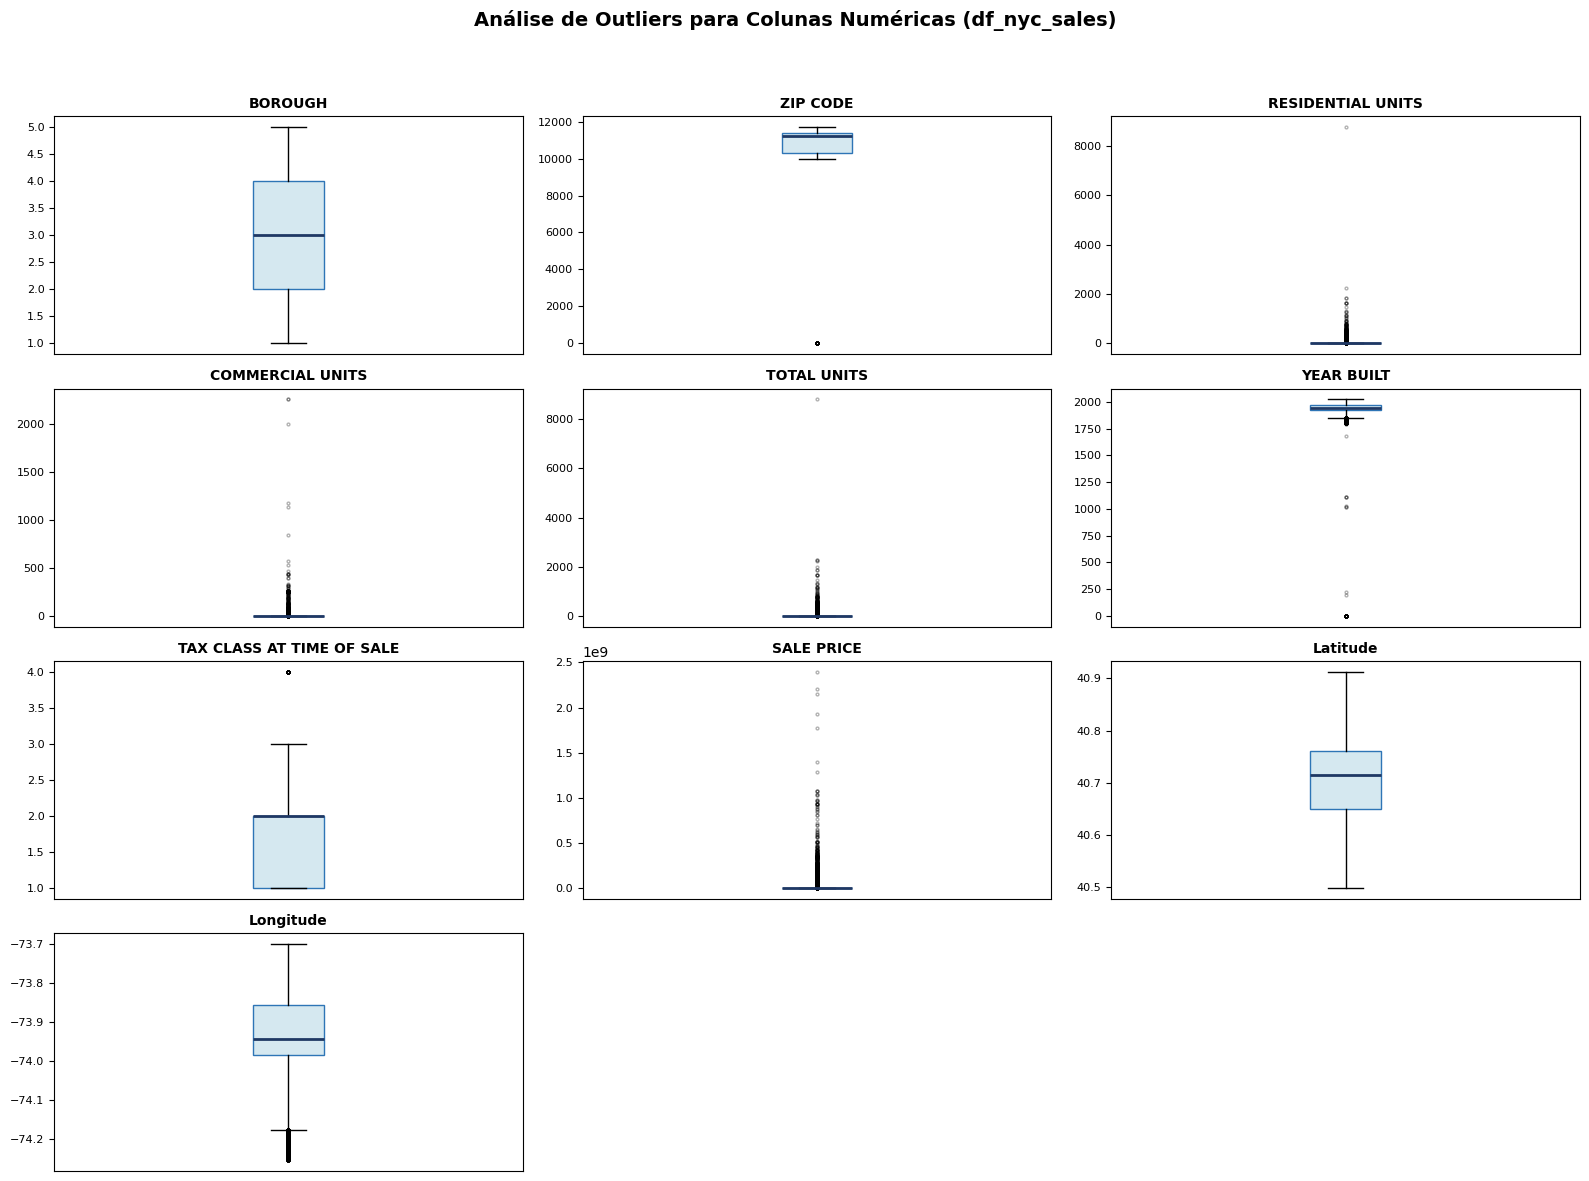

In [9]:
plot_outliers(df_nyc_sales, '(df_nyc_sales)')

As colunas Residential Units, Commercial Units, Total Units, Gross square feet, Year Biuld e sale price apresentaram outliers

####Linhas para dropar, outliers e valores nulos
SALE_PRICE: Nula ou menor que 10.000, valores de 0 a 10.000 geralmente são trocas que não envolvem dinheiro ou heranças, e não vendas reais a preço de mercado. Atualização, Também será retirado os valores maiores que .97 seguindo que a primeira versão dos modelos não se deu bem com outliers mesmo aplicando log.

SALE_DATE: Só é necessário o periodo de 2022-2025

ZIP_CODE: Nulo ou igual a 0, não é possivel integrar com a tabela de crimes nem descobrir se a escola vizinha é boa.

Latitude e Longitude são dados interessantes de ter, por isso vou eliminar as linhas com valores nulos.

Vendas duplicadas: Foram identificados algumas vendas duplicadas.

GROSS SQUARE FEET: Manter no maximo < 50000 e > 100

LAND SQUARE FEET: Lotes acima de 100000 sqft são provavelmente industriais/institucionais, fora do meu escopo

RESIDENTIAL UNITS: apenas pegarei < 70, provavelmente acima são mega edificios, fora do meu escopo.

COMMERCIAL UNITS: Acima de 30 são shoppings/complexos comerciais puros, fora do meu escopo

In [10]:
linhas_antes = df_nyc_sales.shape[0]

df_nyc_sales.drop_duplicates(inplace=True)

df_nyc_sales['SALE DATE'] = pd.to_datetime(df_nyc_sales['SALE DATE'])
df_nyc_sales = df_nyc_sales[df_nyc_sales['SALE DATE'].dt.year.between(2022, 2025)]

df_nyc_sales.dropna(subset=['SALE PRICE'], inplace=True)
df_nyc_sales = df_nyc_sales[df_nyc_sales['SALE PRICE'] > 10000]

cap_value = df_nyc_sales['SALE PRICE'].quantile(0.97)
df_nyc_sales['SALE PRICE'] = df_nyc_sales['SALE PRICE'].clip(upper=cap_value)

df_nyc_sales.dropna(subset=['ZIP CODE'], inplace=True)
df_nyc_sales = df_nyc_sales[df_nyc_sales['ZIP CODE'] > 0]

df_nyc_sales.dropna(subset=['Latitude', 'Longitude'], inplace=True)

for col in ['GROSS SQUARE FEET', 'LAND SQUARE FEET']:
    df_nyc_sales[col] = (
        df_nyc_sales[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace('nan', pd.NA)
    )
    df_nyc_sales[col] = pd.to_numeric(df_nyc_sales[col], errors='coerce')

df_nyc_sales = df_nyc_sales[df_nyc_sales['GROSS SQUARE FEET'].isna() | (df_nyc_sales['GROSS SQUARE FEET'] <= 50000) & (df_nyc_sales['GROSS SQUARE FEET'] > 100)]
df_nyc_sales = df_nyc_sales[df_nyc_sales['LAND SQUARE FEET'].isna()  | (df_nyc_sales['LAND SQUARE FEET']  <= 100000)]
df_nyc_sales = df_nyc_sales[df_nyc_sales['RESIDENTIAL UNITS'].isna() | (df_nyc_sales['RESIDENTIAL UNITS'] <= 70)]
df_nyc_sales = df_nyc_sales[df_nyc_sales['COMMERCIAL UNITS'].isna()  | (df_nyc_sales['COMMERCIAL UNITS']  <= 30)]

df_nyc_sales.dropna(subset=['GROSS SQUARE FEET', 'LAND SQUARE FEET'], inplace=True)

linhas_depois = df_nyc_sales.shape[0]
print(f"linhas removidas: {linhas_antes - linhas_depois} linhas descartadas.")


linhas removidas: 753504 linhas descartadas.


In [11]:
print(f"New shape of df_nyc_sales: {df_nyc_sales.shape}")

New shape of df_nyc_sales: (92103, 17)


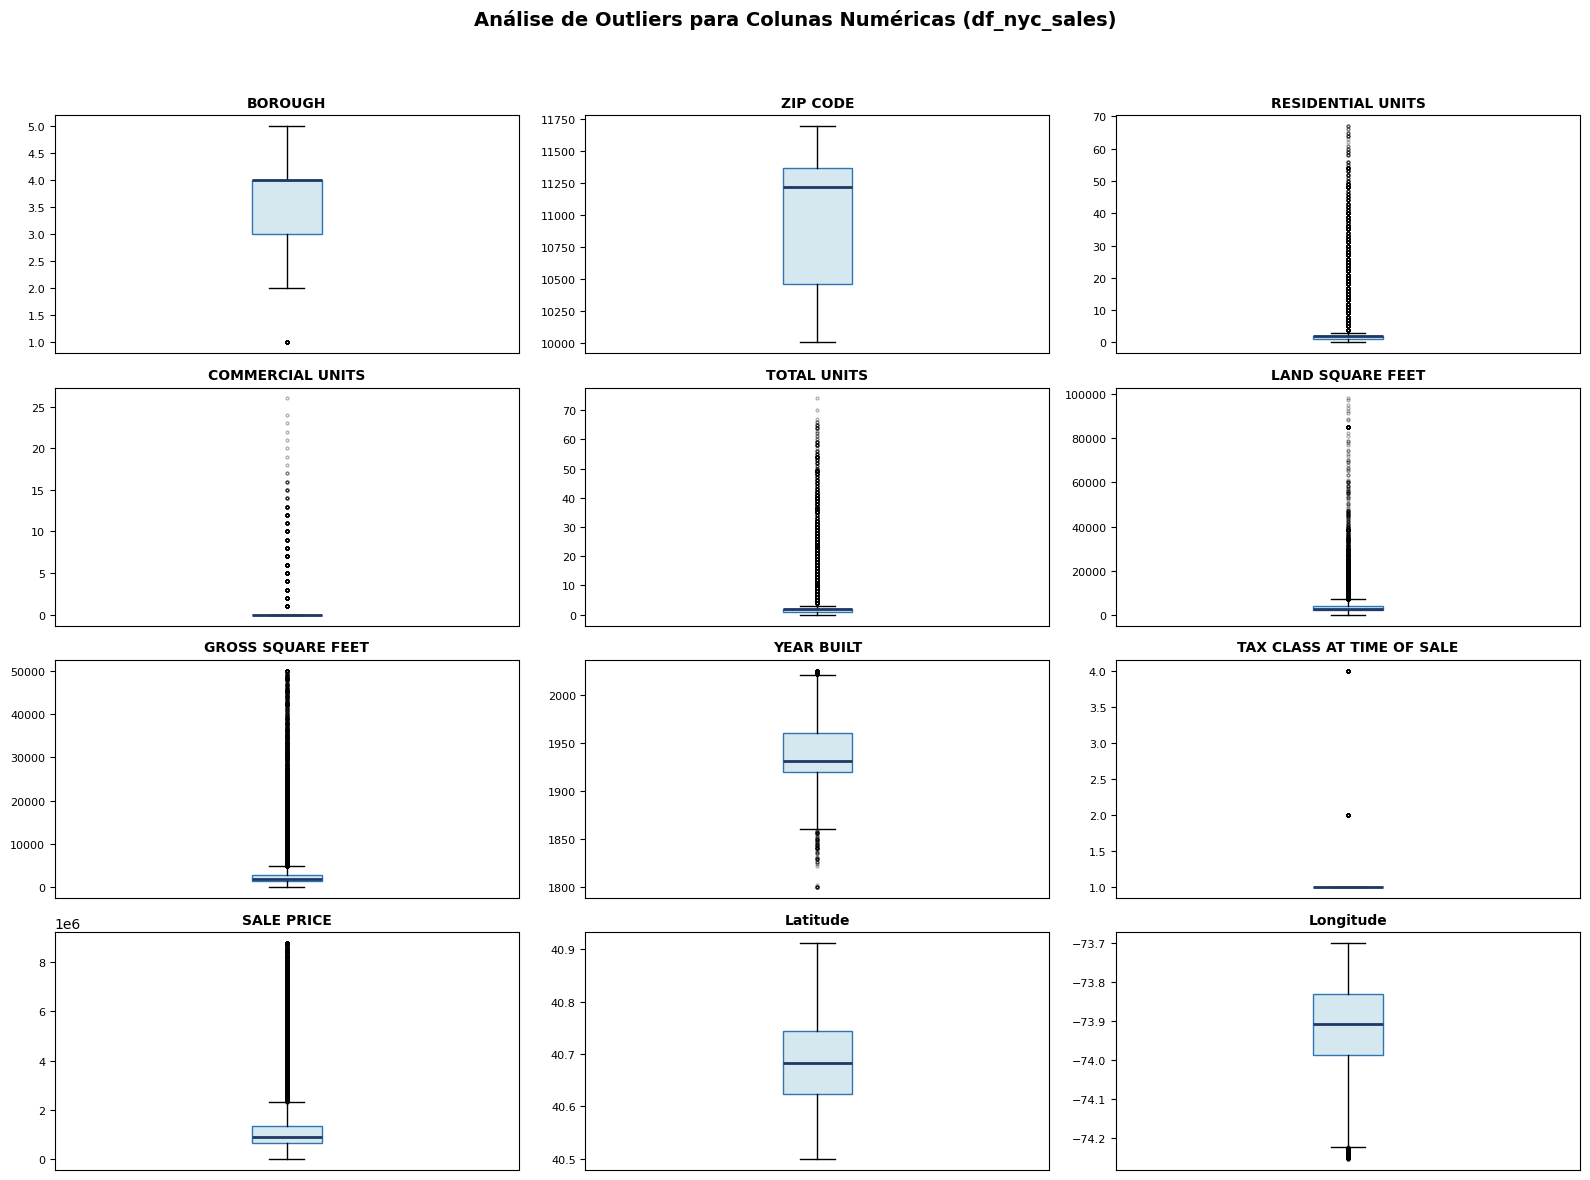

In [12]:
plot_outliers(df_nyc_sales, '(df_nyc_sales)')

In [13]:
display(df_nyc_sales.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
ADDRESS,0
ZIP CODE,0
RESIDENTIAL UNITS,0
COMMERCIAL UNITS,0
TOTAL UNITS,0
LAND SQUARE FEET,0
GROSS SQUARE FEET,0


####Padronizando os dados que seram usados para a integração
Aqui o formato após a conversão é string (YYYY-MM)

Garantindo que o borough ta no formato certo

In [14]:
df_nyc_sales['SALE DATE'] = df_nyc_sales['SALE DATE'].dt.strftime('%Y-%m')
df_nyc_sales['BOROUGH'] = df_nyc_sales['BOROUGH'].astype(int)

In [15]:
if not os.path.exists('dados'):
    os.makedirs('dados')

df_nyc_sales.to_parquet('dados/nyc_vendas_limpo_sem_integracao.parquet', index=False)
print("Dataset de vendas limpo sem integração salvo com sucesso na pasta 'dados'!")

Dataset de vendas limpo sem integração salvo com sucesso na pasta 'dados'!


##Enriquecimento com Fontes Externa

###NYPD Complaint Data Historic

As vezes esses dados não baixam corretamente, se mantenha atento a isso.

####Carregando os dados

In [16]:
print("Iniciando o download do dataset NYPD Complaint Data Historic. Arquivo muito grande! Isso pode levar alguns minutos dependendo da sua internet...")

filename = "nypd_crimes_raw.csv"
url = "https://data.cityofnewyork.us/api/views/qgea-i56i/rows.csv?accessType=DOWNLOAD"

if not os.path.exists(filename):
    try:
        urllib.request.urlretrieve(url, filename)
        tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
        print(f"{filename} baixado com sucesso! Tamanho: {tamanho_mb:.2f} MB")
    except Exception as e:
        print(f"Erro ao baixar {filename}: {e}")
else:
    tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"O arquivo {filename} já existe no diretório. Tamanho: {tamanho_mb:.2f} MB.")

print("Download foi finalizado!")

Iniciando o download do dataset NYPD Complaint Data Historic. Arquivo muito grande! Isso pode levar alguns minutos dependendo da sua internet...
nypd_crimes_raw.csv baixado com sucesso! Tamanho: 3270.30 MB
Download foi finalizado!


####Analisando os dados

In [17]:
con = duckdb.connect()

#####Reduzindo o Dataset para apenas o periodo de 2022-2025

In [18]:
print("Lendo o arquivo e filtrando apenas os anos de 2022 a 2025...")

query = """
    SELECT
        RPT_DT,
        BORO_NM,
        LAW_CAT_CD
    FROM read_csv_auto('nypd_crimes_raw.csv', all_varchar=true)
    WHERE
        CAST(str_split(RPT_DT, '/')[3] AS INTEGER) BETWEEN 2022 AND 2025
"""

df_crimes_filtrados = con.execute(query).df()

print(f"Sucesso! O dataset filtrado tem {df_crimes_filtrados.shape[0]} linhas.")

Lendo o arquivo e filtrando apenas os anos de 2022 a 2025...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Sucesso! O dataset filtrado tem 2243782 linhas.


In [19]:
display(df_crimes_filtrados.head())

,RPT_DT,BORO_NM,LAW_CAT_CD
0,03/15/2022,BRONX,FELONY
1,03/18/2022,BRONX,FELONY
2,06/23/2022,BROOKLYN,FELONY
3,08/20/2022,BRONX,VIOLATION
4,03/08/2022,BRONX,VIOLATION


In [20]:
display(df_crimes_filtrados.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2243782 entries, 0 to 2243781
Data columns (total 3 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   RPT_DT      object
 1   BORO_NM     object
 2   LAW_CAT_CD  object
dtypes: object(3)
memory usage: 51.4+ MB


None

In [21]:
display(df_crimes_filtrados.isnull().sum())

,0
RPT_DT,0
BORO_NM,0
LAW_CAT_CD,0


####Limpando e padronizando os dados

In [22]:
#Data que ocorreu e o nome do distrito
df_crimes = df_crimes_filtrados.dropna(subset=['RPT_DT', 'BORO_NM']).copy()

dict_boroughs = {
    'MANHATTAN': 1,
    'BRONX': 2,
    'BROOKLYN': 3,
    'QUEENS': 4,
    'STATEN ISLAND': 5
}
df_crimes['borough_code'] = df_crimes['BORO_NM'].map(dict_boroughs)

df_crimes.dropna(subset=['borough_code'], inplace=True)

# Criando a chave Ano-Mês no formato YYYY-MM
df_crimes['RPT_DT'] = pd.to_datetime(df_crimes['RPT_DT'], errors='coerce')
df_crimes.dropna(subset=['RPT_DT'], inplace=True)
df_crimes['ano_mes'] = df_crimes['RPT_DT'].dt.strftime('%Y-%m')

#Contando quantos crimes graves e leves ocorreram por Bairro e por Mês
df_crimes_preparado = df_crimes.groupby(['borough_code', 'ano_mes']).apply(
    lambda x: pd.Series({
        'qtd_crimes_graves': (x['LAW_CAT_CD'] == 'FELONY').sum(),
        'qtd_crimes_leves': (x['LAW_CAT_CD'] == 'MISDEMEANOR').sum()
    })
).reset_index()

df_crimes_preparado['borough_code'] = df_crimes_preparado['borough_code'].astype(int)

print(f"Total de linhas agregadas: {df_crimes_preparado.shape[0]}")
display(df_crimes_preparado.head())

Total de linhas agregadas: 240


/tmp/ipykernel_8094/780189284.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_crimes_preparado = df_crimes.groupby(['borough_code', 'ano_mes']).apply(


,borough_code,ano_mes,qtd_crimes_graves,qtd_crimes_leves
0,1,2022-01,3262,4738
1,1,2022-02,3284,5343
2,1,2022-03,3647,6308
3,1,2022-04,3664,5956
4,1,2022-05,3971,6222


In [23]:
if not os.path.exists('dados'):
    os.makedirs('dados')

df_crimes_preparado.to_parquet('dados/crimes_agregados_mensal.parquet', index=False)
print("Arquivo salvo com sucesso na pasta 'dados'!")

Arquivo salvo com sucesso na pasta 'dados'!


###FRED - 30-Year Fixed Rate Mortgage Average

####Carregando os dados

In [24]:
print("Iniciando o download do dataset 30-Year Fixed Rate Mortgage Average.")

filename = "macro_economics_usa.csv"
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US"

if not os.path.exists(filename):
    try:
        urllib.request.urlretrieve(url, filename)
        tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
        print(f"{filename} baixado com sucesso! Tamanho: {tamanho_mb:.2f} MB")
    except Exception as e:
        print(f"Erro ao baixar {filename}: {e}")
else:
    tamanho_mb = os.path.getsize(filename) / (1024 * 1024)
    print(f"O arquivo {filename} já existe no diretório. Tamanho: {tamanho_mb:.2f} MB.")

print("Download foi finalizado!")

Iniciando o download do dataset 30-Year Fixed Rate Mortgage Average.
macro_economics_usa.csv baixado com sucesso! Tamanho: 0.04 MB
Download foi finalizado!


####Analisando os dados

In [25]:
df_juros = pd.read_csv('macro_economics_usa.csv')

display(df_juros.head())

,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [26]:
df_juros['observation_date'] = pd.to_datetime(df_juros['observation_date'], errors='coerce')

# filtrando o dataset para os anos 2022-2025
df_juros = df_juros[df_juros['observation_date'].dt.year.between(2022, 2025)]

df_juros['ano_mes'] = df_juros['observation_date'].dt.strftime('%Y-%m')

display(df_juros.head())

,observation_date,MORTGAGE30US,ano_mes
2649,2022-01-06,3.22,2022-01
2650,2022-01-13,3.45,2022-01
2651,2022-01-20,3.56,2022-01
2652,2022-01-27,3.55,2022-01
2653,2022-02-03,3.55,2022-02


Padronização dos dados para integração

In [27]:
df_juros_preparado = df_juros.groupby('ano_mes')['MORTGAGE30US'].mean().reset_index()

df_juros_preparado.rename(columns={'MORTGAGE30US': 'media_juros_hipoteca'}, inplace=True)

display(df_juros_preparado.head())

,ano_mes,media_juros_hipoteca
0,2022-01,3.4450
1,2022-02,3.7625
2,2022-03,4.1720
3,2022-04,4.9825
4,2022-05,5.2300


###Integrando ao Dataset principal

A integração vai ser pelo codigo de distritos(borough) e mês/ano. Como no dataset principal, o distrito era identificado por id, foi necessário transformar o borough desse dataset em código.

In [28]:
# Bairro e o mês de venda com o bairro e o mês do crime
df_integrado_1 = pd.merge(
    df_nyc_sales,
    df_crimes_preparado,
    left_on=['BOROUGH', 'SALE DATE'],
    right_on=['borough_code', 'ano_mes'],
    how='left'
)

# 'borough_code' ficou duplicado
df_integrado_1.drop(columns=['borough_code'], errors='ignore', inplace=True)

df_dataset_final = pd.merge(
    df_integrado_1,
    df_juros_preparado,
    on='ano_mes',
    how='left'
)

print(f"Integração concluída! O formato final do dataset é: {df_dataset_final.shape}")

Integração concluída! O formato final do dataset é: (92103, 21)


In [29]:
display(df_dataset_final.head())

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,...,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,Latitude,Longitude,ano_mes,qtd_crimes_graves,qtd_crimes_leves,media_juros_hipoteca
0,2,BATHGATE,01 ONE FAMILY DWELLINGS,416 EAST 180TH STREET,10457.0,1.0,0.0,1.0,1575.0,1374.0,...,1,A5,362000,2025-06,40.852139,-73.897621,2025-06,4011,5541,6.8175
1,2,BATHGATE,01 ONE FAMILY DWELLINGS,4449 PARK AVENUE,10457.0,1.0,0.0,1.0,1668.0,1497.0,...,1,A1,520000,2025-09,40.853545,-73.896014,2025-09,3886,5419,6.3525
2,2,BATHGATE,01 ONE FAMILY DWELLINGS,2058 BATHGATE AVENUE,10457.0,1.0,0.0,1.0,1173.0,1516.0,...,1,A1,500000,2025-12,40.850237,-73.895253,2025-12,3190,4867,6.1900
3,2,BATHGATE,01 ONE FAMILY DWELLINGS,4447 PARK AVENUE,10457.0,1.0,0.0,1.0,1668.0,1497.0,...,1,A1,615000,2024-12,40.853515,-73.896028,2024-12,3269,5063,6.7150
4,2,BATHGATE,01 ONE FAMILY DWELLINGS,2327 BASSFORD AVENUE,10458.0,1.0,0.0,1.0,913.0,1248.0,...,1,A1,655000,2025-12,40.855847,-73.891755,2025-12,3190,4867,6.1900


In [30]:
display(df_dataset_final.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
ADDRESS,0
ZIP CODE,0
RESIDENTIAL UNITS,0
COMMERCIAL UNITS,0
TOTAL UNITS,0
LAND SQUARE FEET,0
GROSS SQUARE FEET,0


In [31]:
df_dataset_final.to_parquet('dados/nyc_vendas_integrado_bruto.parquet', index=False)

##Limpeza de Dados

###Missing values

####Aplicando KNN-Imputer

Na primeira versão, foi as colunas GROSS SQUARE FEET e LAND SQUARE FEET não eram retiradas os nulos, mas decidi retirar a maioria por conta de outliers

In [32]:
from tqdm.notebook import tqdm #adição da barrinha de progresso

for col in ['GROSS SQUARE FEET', 'LAND SQUARE FEET']:
    df_dataset_final[col] = pd.to_numeric(df_dataset_final[col].astype(str).str.replace(',', ''), errors='coerce')

pedacos_imputados = []

#aqui fiz por bairro apenas para poder acompanhar o progresso
for bairro, df_bairro in tqdm(df_dataset_final.groupby('BOROUGH'), desc="Processando Bairros"):

    colunas_knn = ['YEAR BUILT', 'GROSS SQUARE FEET', 'LAND SQUARE FEET']
    df_num = df_bairro[colunas_knn].copy()

    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns, index=df_num.index)

    imputer = KNNImputer(n_neighbors=5, weights='distance')
    df_imputed_scaled = pd.DataFrame(imputer.fit_transform(df_scaled), columns=df_num.columns, index=df_num.index)

    df_imputed = pd.DataFrame(scaler.inverse_transform(df_imputed_scaled), columns=df_num.columns, index=df_num.index)

    df_bairro_pronto = df_bairro.copy()
    for col in colunas_knn:
        df_bairro_pronto[col] = df_imputed[col]

    pedacos_imputados.append(df_bairro_pronto)

df_dataset_final = pd.concat(pedacos_imputados).sort_index()

print("Imputação com KNN concluída")

Processando Bairros:   0%|          | 0/5 [00:00<?, ?it/s]

Imputação com KNN concluída


In [33]:
display(df_dataset_final.isnull().sum())

,0
BOROUGH,0
NEIGHBORHOOD,0
BUILDING CLASS CATEGORY,0
ADDRESS,0
ZIP CODE,0
RESIDENTIAL UNITS,0
COMMERCIAL UNITS,0
TOTAL UNITS,0
LAND SQUARE FEET,0
GROSS SQUARE FEET,0


In [34]:
display(df_dataset_final.head())

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,...,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,Latitude,Longitude,ano_mes,qtd_crimes_graves,qtd_crimes_leves,media_juros_hipoteca
0,2,BATHGATE,01 ONE FAMILY DWELLINGS,416 EAST 180TH STREET,10457.0,1.0,0.0,1.0,1575.0,1374.0,...,1,A5,362000.0,2025-06,40.852139,-73.897621,2025-06,4011,5541,6.8175
1,2,BATHGATE,01 ONE FAMILY DWELLINGS,4449 PARK AVENUE,10457.0,1.0,0.0,1.0,1668.0,1497.0,...,1,A1,520000.0,2025-09,40.853545,-73.896014,2025-09,3886,5419,6.3525
2,2,BATHGATE,01 ONE FAMILY DWELLINGS,2058 BATHGATE AVENUE,10457.0,1.0,0.0,1.0,1173.0,1516.0,...,1,A1,500000.0,2025-12,40.850237,-73.895253,2025-12,3190,4867,6.1900
3,2,BATHGATE,01 ONE FAMILY DWELLINGS,4447 PARK AVENUE,10457.0,1.0,0.0,1.0,1668.0,1497.0,...,1,A1,615000.0,2024-12,40.853515,-73.896028,2024-12,3269,5063,6.7150
4,2,BATHGATE,01 ONE FAMILY DWELLINGS,2327 BASSFORD AVENUE,10458.0,1.0,0.0,1.0,913.0,1248.0,...,1,A1,655000.0,2025-12,40.855847,-73.891755,2025-12,3190,4867,6.1900


###Inconsistências

In [35]:
df_dataset_final['TOTAL UNITS'] = df_dataset_final['RESIDENTIAL UNITS'] + df_dataset_final['COMMERCIAL UNITS']

###Padronização

In [36]:
df_dataset_final['ZIP CODE'] = df_dataset_final['ZIP CODE'].astype(int).astype(str)
df_dataset_final['NEIGHBORHOOD'] = df_dataset_final['NEIGHBORHOOD'].str.strip().str.upper()
df_dataset_final['BUILDING CLASS CATEGORY'] = df_dataset_final['BUILDING CLASS CATEGORY'].str.strip().str.upper()

if 'ano_mes' in df_dataset_final.columns:
    df_dataset_final.drop(columns=['ano_mes'], inplace=True)


##Dataset Final

In [37]:
display(df_dataset_final.head())
display(df_dataset_final.info())
df_dataset_final.to_parquet('dados/nyc_dados_finais_limpos.parquet', index=False)

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,ADDRESS,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE,Latitude,Longitude,qtd_crimes_graves,qtd_crimes_leves,media_juros_hipoteca
0,2,BATHGATE,01 ONE FAMILY DWELLINGS,416 EAST 180TH STREET,10457,1.0,0.0,1.0,1575.0,1374.0,1899.0,1,A5,362000.0,2025-06,40.852139,-73.897621,4011,5541,6.8175
1,2,BATHGATE,01 ONE FAMILY DWELLINGS,4449 PARK AVENUE,10457,1.0,0.0,1.0,1668.0,1497.0,1899.0,1,A1,520000.0,2025-09,40.853545,-73.896014,3886,5419,6.3525
2,2,BATHGATE,01 ONE FAMILY DWELLINGS,2058 BATHGATE AVENUE,10457,1.0,0.0,1.0,1173.0,1516.0,1910.0,1,A1,500000.0,2025-12,40.850237,-73.895253,3190,4867,6.1900
3,2,BATHGATE,01 ONE FAMILY DWELLINGS,4447 PARK AVENUE,10457,1.0,0.0,1.0,1668.0,1497.0,1899.0,1,A1,615000.0,2024-12,40.853515,-73.896028,3269,5063,6.7150
4,2,BATHGATE,01 ONE FAMILY DWELLINGS,2327 BASSFORD AVENUE,10458,1.0,0.0,1.0,913.0,1248.0,1901.0,1,A1,655000.0,2025-12,40.855847,-73.891755,3190,4867,6.1900


<class 'pandas.core.frame.DataFrame'>
Index: 92103 entries, 0 to 92102
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   BOROUGH                         92103 non-null  int64  
 1   NEIGHBORHOOD                    92103 non-null  object 
 2   BUILDING CLASS CATEGORY         92103 non-null  object 
 3   ADDRESS                         92103 non-null  object 
 4   ZIP CODE                        92103 non-null  object 
 5   RESIDENTIAL UNITS               92103 non-null  float64
 6   COMMERCIAL UNITS                92103 non-null  float64
 7   TOTAL UNITS                     92103 non-null  float64
 8   LAND SQUARE FEET                92103 non-null  float64
 9   GROSS SQUARE FEET               92103 non-null  float64
 10  YEAR BUILT                      92103 non-null  float64
 11  TAX CLASS AT TIME OF SALE       92103 non-null  int64  
 12  BUILDING CLASS AT TIME OF SALE  92103

None

O Dataset final ficou com 84968 linhas e 20 colunas. Para fins de comparação, outro dataset das vendas sem a integração também foi criado.

##Análise Exploratória e Consultas SQL

###Reestruturação Necessária


####Normalização da Data

In [38]:
df_dataset_final['SALE DATE'] = pd.to_datetime(df_dataset_final['SALE DATE'])
df_dataset_final['sale_year'] = df_dataset_final['SALE DATE'].dt.year
df_dataset_final['sale_month'] = df_dataset_final['SALE DATE'].dt.month
df_dataset_final['sale_day_of_week'] = df_dataset_final['SALE DATE'].dt.dayofweek


####Corrigindo alguns tipos numéricos

In [39]:
cols_para_int = ['RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS', 'YEAR BUILT']
for col in cols_para_int:
    df_dataset_final[col] = df_dataset_final[col].astype(int)

####Padronização de tipos

In [40]:
cols_categoricas = [
    'BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY',
    'ZIP CODE', 'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE'
]
for col in cols_categoricas:
    df_dataset_final[col] = df_dataset_final[col].astype('category')

cols_para_remover = ['ADDRESS', 'SALE DATE']
df_dataset_final.drop(columns=cols_para_remover, inplace=True, errors='ignore')

####parquet final limpo 2.0

In [41]:
df_dataset_final.to_parquet('dados/nyc_dados_finais_limpos_v2.parquet', index=False)
print(df_dataset_final.info())

<class 'pandas.core.frame.DataFrame'>
Index: 92103 entries, 0 to 92102
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   BOROUGH                         92103 non-null  category
 1   NEIGHBORHOOD                    92103 non-null  category
 2   BUILDING CLASS CATEGORY         92103 non-null  category
 3   ZIP CODE                        92103 non-null  category
 4   RESIDENTIAL UNITS               92103 non-null  int64   
 5   COMMERCIAL UNITS                92103 non-null  int64   
 6   TOTAL UNITS                     92103 non-null  int64   
 7   LAND SQUARE FEET                92103 non-null  float64 
 8   GROSS SQUARE FEET               92103 non-null  float64 
 9   YEAR BUILT                      92103 non-null  int64   
 10  TAX CLASS AT TIME OF SALE       92103 non-null  category
 11  BUILDING CLASS AT TIME OF SALE  92103 non-null  category
 12  SALE PRICE             

###Consultas SQL

In [42]:
path_parquet = 'dados/nyc_dados_finais_limpos_v2.parquet'

####Análise Macro por Bairro

Analisa o preço por bairro e verefica o preço por metro quadrado

In [43]:
query1 = f"""
    SELECT
        BOROUGH,
        COUNT(*) as total_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio,
        ROUND(AVG("GROSS SQUARE FEET"), 2) as area_media,
        ROUND(AVG("SALE PRICE") / NULLIF(AVG("GROSS SQUARE FEET"), 0), 2) as preco_por_sqft,
        ROUND(AVG(qtd_crimes_graves), 0) as media_crimes_graves_mes
    FROM '{path_parquet}'
    GROUP BY BOROUGH
    ORDER BY preco_medio DESC
"""

df_analise_bairros = con.execute(query1).df()
display(df_analise_bairros)

,BOROUGH,total_vendas,preco_medio,area_media,preco_por_sqft,media_crimes_graves_mes
0,1,3288,5201403.39,9851.50,527.98,3769.0
1,3,27678,1705916.84,3049.83,559.35,4271.0
2,4,34997,1073416.46,2157.83,497.45,3378.0
3,2,10065,1072945.01,3672.73,292.14,3500.0
4,5,16075,780586.36,1882.80,414.59,535.0


/tmp/ipykernel_8094/3243275923.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_analise_bairros, x='BOROUGH', y='preco_por_sqft', palette='viridis')


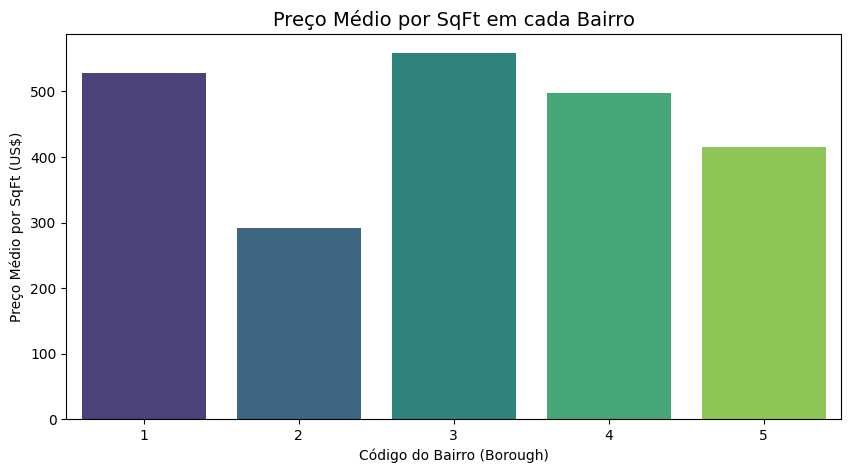

In [44]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_analise_bairros, x='BOROUGH', y='preco_por_sqft', palette='viridis')
plt.title('Preço Médio por SqFt em cada Bairro', fontsize=14)
plt.xlabel('Código do Bairro (Borough)')
plt.ylabel('Preço Médio por SqFt (US$)')
plt.show()

todo: alterar nome no grafico

    'MANHATTAN': 1,
    'BRONX': 2,
    'BROOKLYN': 3,
    'QUEENS': 4,
    'STATEN ISLAND': 5


####Impacto dos Juros



Analisando se a taxa de juros impacta de alguma forma o volume de vendas:

In [45]:
query2 = f"""
    SELECT
        media_juros_hipoteca,
        COUNT(*) as volume_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio
    FROM '{path_parquet}'
    GROUP BY media_juros_hipoteca
    ORDER BY media_juros_hipoteca ASC
"""

df_juros = con.execute(query2).df()
display(df_juros)

,media_juros_hipoteca,volume_vendas,preco_medio
0,3.4450,2348,1314589.55
1,3.7625,2268,1278913.33
2,4.1720,2629,1333755.56
3,4.9825,2191,1301174.98
4,5.2225,2409,1337901.22
5,5.2300,2564,1410578.30
6,5.4125,2364,1376256.07
7,5.5220,2800,1421020.62
8,6.1120,2173,1390431.94
9,6.1800,1920,1444153.44


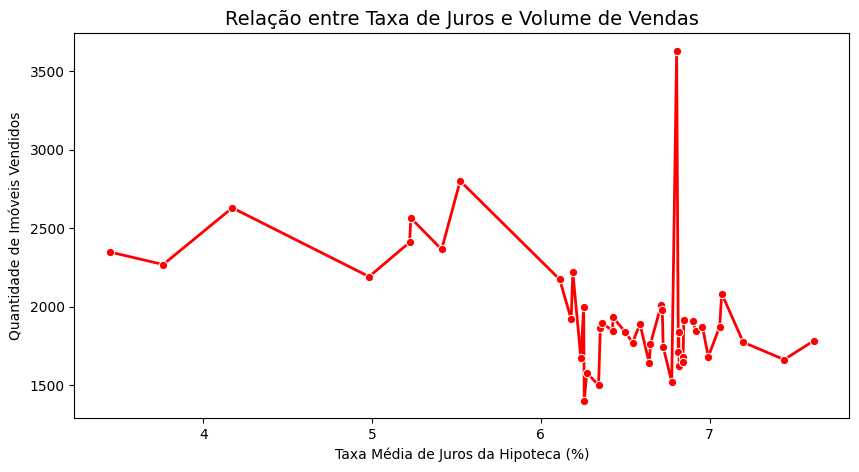

In [46]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_juros, x='media_juros_hipoteca', y='volume_vendas', marker='o', color='red', linewidth=2)
plt.title('Relação entre Taxa de Juros e Volume de Vendas', fontsize=14)
plt.xlabel('Taxa Média de Juros da Hipoteca (%)')
plt.ylabel('Quantidade de Imóveis Vendidos')
plt.show()

####Categorias de Imóveis vs Crimes

Verifica se os imóveis populares estão localizados em zonas com médias criminais mais altas em comparação aos imóveis de luxo.

In [47]:
query3 = f"""
    SELECT
        CASE
            WHEN "SALE PRICE" >= 2000000 THEN '1. Luxo (> $2M)'
            WHEN "SALE PRICE" < 500000 THEN '3. Popular (< $500k)'
            ELSE '2. Intermediário'
        END as categoria_imovel,
        COUNT(*) as qtd_vendas,
        ROUND(AVG(qtd_crimes_graves), 0) as media_crimes_graves,
        ROUND(AVG(qtd_crimes_leves), 0) as media_crimes_leves
    FROM '{path_parquet}'
    GROUP BY categoria_imovel
    ORDER BY categoria_imovel ASC
"""

df_luxo = con.execute(query3).df()
display(df_luxo)

,categoria_imovel,qtd_vendas,media_crimes_graves,media_crimes_leves
0,1. Luxo (> $2M),11702,3891.0,5999.0
1,2. Intermediário,71273,3114.0,4784.0
2,3. Popular (< $500k),9128,2757.0,4258.0


/tmp/ipykernel_8094/4277088676.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_luxo, x='categoria_imovel', y='media_crimes_graves', palette='magma')


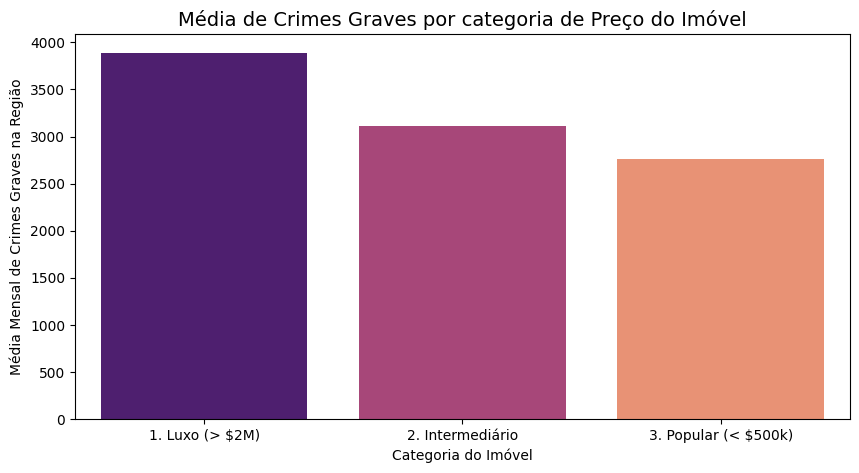

In [48]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_luxo, x='categoria_imovel', y='media_crimes_graves', palette='magma')
plt.title('Média de Crimes Graves por categoria de Preço do Imóvel', fontsize=14)
plt.xlabel('Categoria do Imóvel')
plt.ylabel('Média Mensal de Crimes Graves na Região')
plt.show()

Esse resultado pode ser explicado pela teoria da centralidade urbana e densidade demográfica de Nova York. Os imóveis de altíssimo padrão estão concentrados no núcleo central da cidade, regiões que atraem diariamente milhões de trabalhadores e turistas, além de concentrarem grande fluxo de capital. Essa extrema densidade de oportunidades eleva os números absolutos de registros criminais nas delegacias locais. Por outro lado, o mercado 'Popular' se localiza em zonas periféricas e predominantemente residenciais dos distritos externos, que possuem menor densidade populacional flutuante e, consequentemente, menor contagem absoluta de ocorrências.

####Sazonalidade de Vendas e Crimes

Verifica se há picos de vendas em algum mês e se há alguma correlação com o aumento da criminalidade nessas épocas.

In [49]:
query4 = f"""
    SELECT
        sale_month as mes,
        COUNT(*) as total_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio_venda,
        ROUND(AVG(qtd_crimes_graves), 0) as media_crimes_graves
    FROM '{path_parquet}'
    GROUP BY sale_month
    ORDER BY sale_month ASC
"""

df_sazonalidade = con.execute(query4).df()
display(df_sazonalidade)

,mes,total_vendas,preco_medio_venda,media_crimes_graves
0,1,7440,1340033.13,3021.0
1,2,6836,1307027.84,2818.0
2,3,7783,1327666.56,3097.0
3,4,7114,1343528.43,3090.0
4,5,8124,1358777.85,3330.0
5,6,8498,1437620.81,3274.0
6,7,7935,1384869.95,3423.0
7,8,8222,1321364.29,3397.0
8,9,7728,1401227.85,3287.0
9,10,7624,1323077.35,3275.0


/tmp/ipykernel_8094/104706544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sazonalidade, x='mes', y='total_vendas', palette='Blues_d')


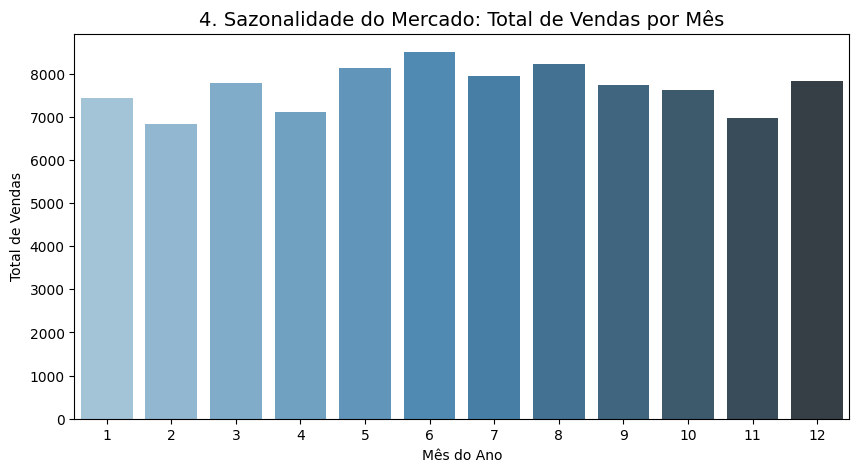

/tmp/ipykernel_8094/104706544.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sazonalidade, x='mes', y='media_crimes_graves', palette='Reds_d')


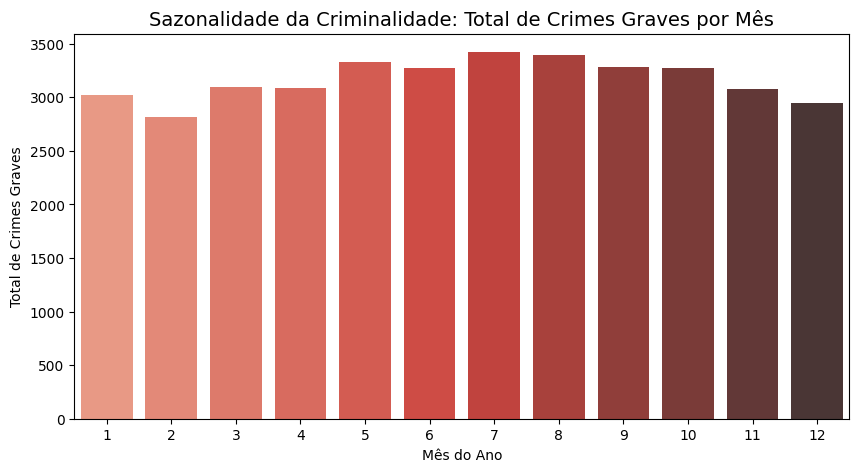

In [50]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_sazonalidade, x='mes', y='total_vendas', palette='Blues_d')
plt.title('4. Sazonalidade do Mercado: Total de Vendas por Mês', fontsize=14)
plt.xlabel('Mês do Ano')
plt.ylabel('Total de Vendas')
plt.show()
plt.figure(figsize=(10, 5))
sns.barplot(data=df_sazonalidade, x='mes', y='media_crimes_graves', palette='Reds_d')
plt.title('Sazonalidade da Criminalidade: Total de Crimes Graves por Mês', fontsize=14)
plt.xlabel('Mês do Ano')
plt.ylabel('Total de Crimes Graves')
plt.show()

Essa correlação evidencia o fator climático/sazonal como uma variável de confusão: meses mais quentes aumentam a circulação de capital e pessoas, aquecendo o mercado imobiliário, mas também aumentando a exposição a crimes. Para a etapa de Machine Learning, isso justifica a manutenção da variável 'Mês', para que o algoritmo não penalize erroneamente o preço de um imóvel vendido em Julho apenas por causa do pico natural de crimes daquela época.

####Micro-localização

Mostra ao avaliador os bairros específicos mais valorizados e com liquidez

In [51]:
query5 = f"""
    SELECT
        NEIGHBORHOOD,
        BOROUGH,
        COUNT(*) as volume_vendas,
        ROUND(AVG("SALE PRICE"), 2) as preco_medio
    FROM '{path_parquet}'
    GROUP BY NEIGHBORHOOD, BOROUGH
    HAVING COUNT(*) > 100
    ORDER BY preco_medio DESC
    LIMIT 10
"""

df_top_bairros = con.execute(query5).df()
display(df_top_bairros)

,NEIGHBORHOOD,BOROUGH,volume_vendas,preco_medio
0,GREENWICH VILLAGE-WEST,1,232,7195808.23
1,UPPER EAST SIDE (59-79),1,272,6880949.69
2,UPPER EAST SIDE (79-96),1,191,6749130.91
3,EAST VILLAGE,1,118,6468912.75
4,CHELSEA,1,144,6386239.32
5,BROOKLYN HEIGHTS,3,156,6119789.63
6,WILLIAMSBURG-NORTH,3,166,5516658.32
7,UPPER WEST SIDE (79-96),1,167,5306203.71
8,COBBLE HILL,3,124,4785895.50
9,PARK SLOPE,3,552,4120575.77


/tmp/ipykernel_8094/4006602141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_bairros, y='NEIGHBORHOOD', x='preco_medio', palette='rocket')


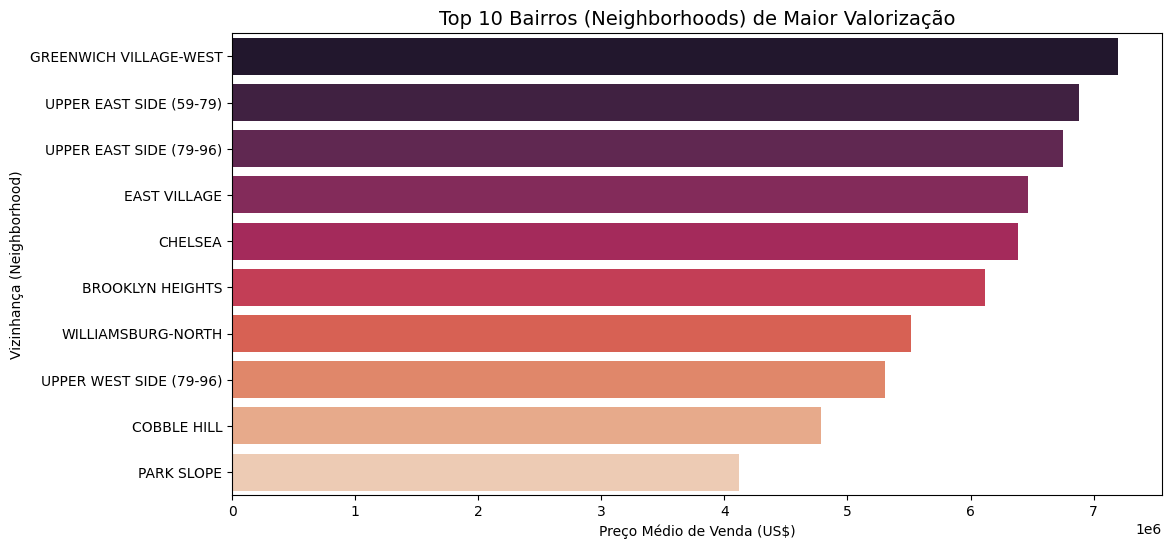

In [52]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_bairros, y='NEIGHBORHOOD', x='preco_medio', palette='rocket')
plt.title('Top 10 Bairros (Neighborhoods) de Maior Valorização', fontsize=14)
plt.xlabel('Preço Médio de Venda (US$)')
plt.ylabel('Vizinhança (Neighborhood)')
plt.show()

####H1: Crimes graves impactam mais imóveis residenciais?

Para testar a Hipótese 1, realizamos uma agregação dos dados em formato de painel , agrupando as transações por Distrito, Mês de Venda e Tipo de Imóvel

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


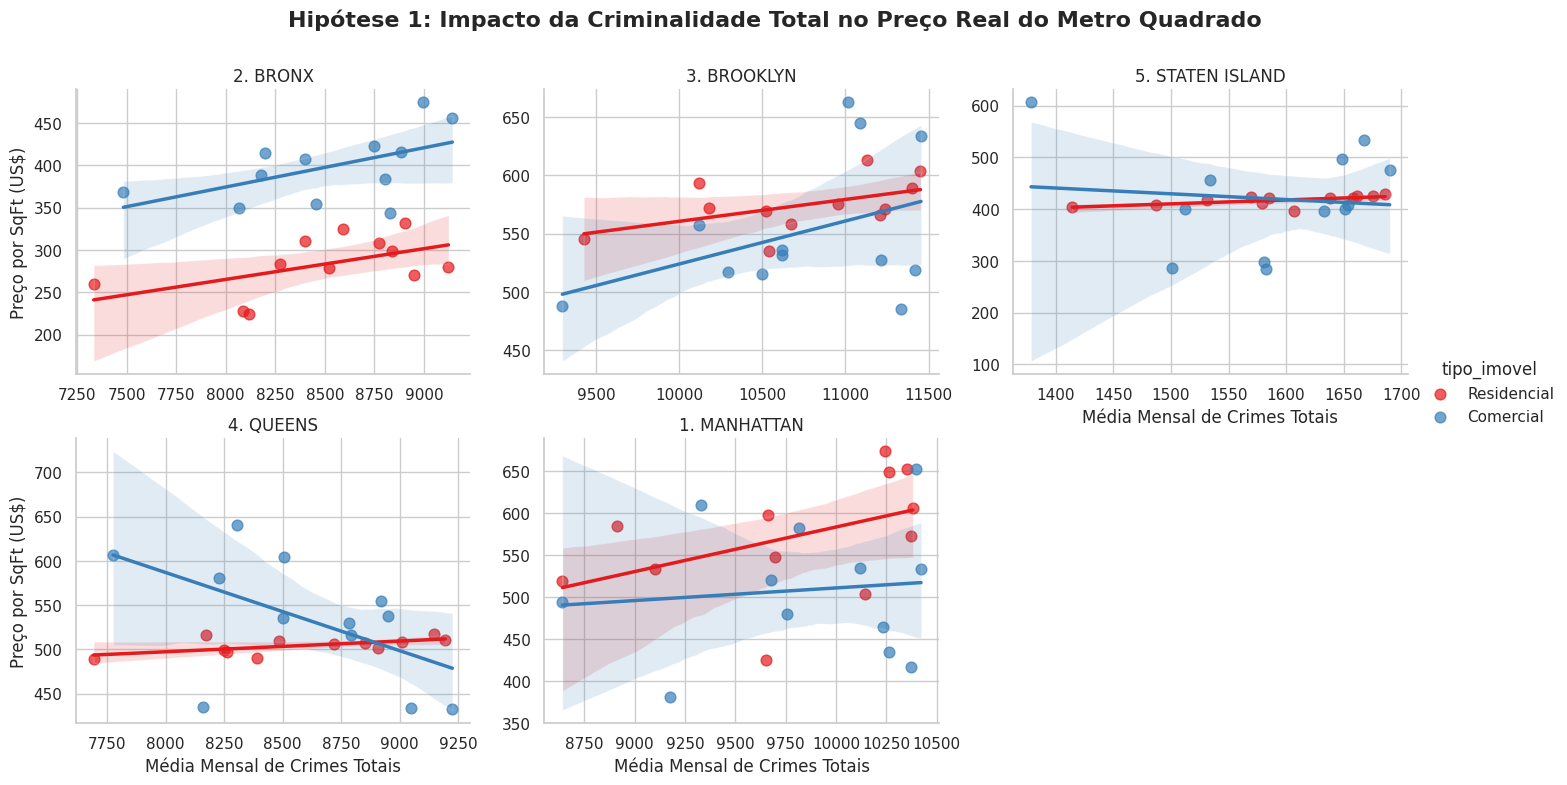

In [53]:
query_h1_otimizada = f"""
    SELECT
        CASE BOROUGH
            WHEN 1 THEN '1. MANHATTAN'
            WHEN 2 THEN '2. BRONX'
            WHEN 3 THEN '3. BROOKLYN'
            WHEN 4 THEN '4. QUEENS'
            WHEN 5 THEN '5. STATEN ISLAND'
        END AS nome_bairro,
        sale_month,
        CASE
            WHEN "RESIDENTIAL UNITS" > 0 AND "COMMERCIAL UNITS" = 0 THEN 'Residencial'
            WHEN "COMMERCIAL UNITS" > 0 AND "RESIDENTIAL UNITS" = 0 THEN 'Comercial'
            ELSE 'Misto'
        END AS tipo_imovel,
        AVG(qtd_crimes_graves + qtd_crimes_leves) AS media_crimes_total,
        SUM("SALE PRICE") / NULLIF(SUM("GROSS SQUARE FEET"), 0) AS preco_medio_sqft
    FROM '{path_parquet}'
    WHERE "GROSS SQUARE FEET" > 100
      AND "SALE PRICE" > 10000
    GROUP BY BOROUGH, sale_month, tipo_imovel
    HAVING tipo_imovel IN ('Residencial', 'Comercial')
"""

df_h1 = con.execute(query_h1_otimizada).df()

sns.set_theme(style="whitegrid")

g = sns.lmplot(
    data=df_h1,
    x="media_crimes_total",
    y="preco_medio_sqft",
    hue="tipo_imovel",
    col="nome_bairro",
    col_wrap=3,
    palette="Set1",
    height=4,
    aspect=1.2,
    sharey=False,
    sharex=False,
    scatter_kws={'alpha': 0.7, 's': 60},
    line_kws={'linewidth': 2.5}
)

g.set_axis_labels("Média Mensal de Crimes Totais", "Preço por SqFt (US$)")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle(
    'Hipótese 1: Impacto da Criminalidade Total no Preço Real do Metro Quadrado',
    fontsize=16, fontweight='bold'
)

plt.show()

Apenas MANHATTAN está de acordo com a hipótese, nos outros distritos ou ambas linhas estão de acordo como em BRONX, ou o tipo de imóvel comercial teve mais impacto.

STATEN ISLAND é um distrito muito mais pacato, residencial e isolado. Pela baixa quantidade de crimes e comportamento de "subúrbio", o impacto visual é bem menor e as linhas são mais curtas.

In [54]:
linhas_tabela = []
for (bairro, tipo), grupo in df_h1.groupby(['nome_bairro', 'tipo_imovel']):
    correlacao = grupo['media_crimes_total'].corr(grupo['preco_medio_sqft']) \
                 if len(grupo) > 1 else np.nan
    linhas_tabela.append({
        'Distrito (Borough)'     : bairro,
        'Tipo de Imóvel'         : tipo,
        'Média Crimes/Mês (total)': round(grupo['media_crimes_total'].mean(), 1),
        'Preço Médio/SqFt'       : f"${grupo['preco_medio_sqft'].mean():,.2f}",
        'Correlação (r)'         : round(correlacao, 3) if pd.notna(correlacao) else 'N/A'
    })

df_resumo_h1 = pd.DataFrame(linhas_tabela)
display(df_resumo_h1)

,Distrito (Borough),Tipo de Imóvel,Média Crimes/Mês (total),Preço Médio/SqFt,Correlação (r)
0,1. MANHATTAN,Comercial,9850.2,$508.73,0.106
1,1. MANHATTAN,Residencial,9784.6,$572.06,0.457
2,2. BRONX,Comercial,8515.2,$398.41,0.532
3,2. BRONX,Residencial,8492.9,$283.15,0.521
4,3. BROOKLYN,Comercial,10747.2,$551.49,0.385
5,3. BROOKLYN,Residencial,10736.6,$574.38,0.504
6,4. QUEENS,Comercial,8599.5,$533.87,-0.534
7,4. QUEENS,Residencial,8589.9,$504.41,0.612
8,5. STATEN ISLAND,Comercial,1586.0,$419.95,-0.101
9,5. STATEN ISLAND,Residencial,1591.1,$416.94,0.635


Utilizando Correlação Spearman para h1

In [55]:
print('Total de crimes × Preço por sqft (Residencial vs Comercial)')

df_h1 = df_dataset_final.copy()
df_h1['preco_por_sqft'] = df_h1['SALE PRICE'] / df_h1['GROSS SQUARE FEET'].replace(0, float('nan'))

# Total de crimes = graves + leves
df_h1['qtd_crimes_total'] = df_h1['qtd_crimes_graves'] + df_h1['qtd_crimes_leves']

df_h1 = df_h1.dropna(subset=['preco_por_sqft', 'qtd_crimes_total'])

df_h1['tipo_imovel'] = df_h1['RESIDENTIAL UNITS'].apply(
    lambda x: 'Residencial' if x > 0 else 'Comercial'
)

for tipo in ['Residencial', 'Comercial']:
    subset = df_h1[df_h1['tipo_imovel'] == tipo]
    r, p = stats.spearmanr(subset['qtd_crimes_total'], subset['preco_por_sqft'])
    sig = 'Significativo (p < 0.05)' if p < 0.05 else 'Não significativo'
    print(f'  [{tipo}]  rho = {r:+.4f}  |  p-value = {p:.4e}  →  {sig}')

print()
print('Interpretação:')
print('Se |rho| for maior para Residencial, H1 é apoiada pelos dados.')
print('Correlação negativa (rho < 0) = mais crimes → menor preço/sqft.')

Total de crimes × Preço por sqft (Residencial vs Comercial)
  [Residencial]  rho = +0.1923  |  p-value = 0.0000e+00  →  Significativo (p < 0.05)
  [Comercial]  rho = +0.1284  |  p-value = 2.0878e-16  →  Significativo (p < 0.05)

Interpretação:
Se |rho| for maior para Residencial, H1 é apoiada pelos dados.
Correlação negativa (rho < 0) = mais crimes → menor preço/sqft.


Analisando a tabela e o resultado do teste, podemos dizer que os imóveis comerciais são menos afetados, apesar de ser por uma margem pequena, nota-se na tabela que a correlação do residencial é mais afetada pela média de crimes. Agora analisando o teste, o rho foi maior para o Residencial, apoiando a H1. Entretando, é interessante observar o caso de Bronx, onde os preços sobemn com a quantia de crimes o que refutaria a H1 parcialmente(culpa minha ter feito uma h1 confusa), nesse caso é interessante notar que muito provavelmente esse teste está capturando o efeito de densidade urbana, e não o efeito do crime sobre o preço.

####H2: Taxa de Juros × Volume de Vendas Mensal (Spearman)

In [56]:
print('\nTaxa de Juros vs Volume de Vendas Mensal')

df_h2 = df_dataset_final.copy()

df_h2['ano_mes'] = (
    df_h2['sale_year'].astype(str) + '-' +
    df_h2['sale_month'].astype(str).str.zfill(2)
)

vendas_mensais = df_h2.groupby('ano_mes').agg(
    volume_vendas=('SALE PRICE', 'count'),
    media_preco=('SALE PRICE', 'median'),
    juros=('media_juros_hipoteca', 'mean')
).reset_index().dropna()

# Spearman — juros vs volume
r_vol, p_vol = stats.spearmanr(vendas_mensais['juros'], vendas_mensais['volume_vendas'])
sig_vol = 'Significativo (p < 0.05)' if p_vol < 0.05 else 'Não significativo'

# Spearman — juros vs preço mediano
r_preco, p_preco = stats.spearmanr(vendas_mensais['juros'], vendas_mensais['media_preco'])
sig_preco = 'Significativo (p < 0.05)' if p_preco < 0.05 else 'Não significativo'

print(f'Juros × Volume de Vendas:  rho = {r_vol:+.4f}  |  p = {p_vol:.4e}  →  {sig_vol}')
print(f'Juros × Preço Mediano:     rho = {r_preco:+.4f}  |  p = {p_preco:.4e}  →  {sig_preco}')

print()
print('Interpretação:')
print('rho negativo e significativo = H2 apoiada: juros altos reduzem volume/preço.')
print('rho positivo ou não-significativo = H2 não encontra suporte estatístico claro.')


Taxa de Juros vs Volume de Vendas Mensal
Juros × Volume de Vendas:  rho = -0.4835  |  p = 4.9948e-04  →  Significativo (p < 0.05)
Juros × Preço Mediano:     rho = -0.0826  |  p = 5.7687e-01  →  Não significativo

Interpretação:
rho negativo e significativo = H2 apoiada: juros altos reduzem volume/preço.
rho positivo ou não-significativo = H2 não encontra suporte estatístico claro.


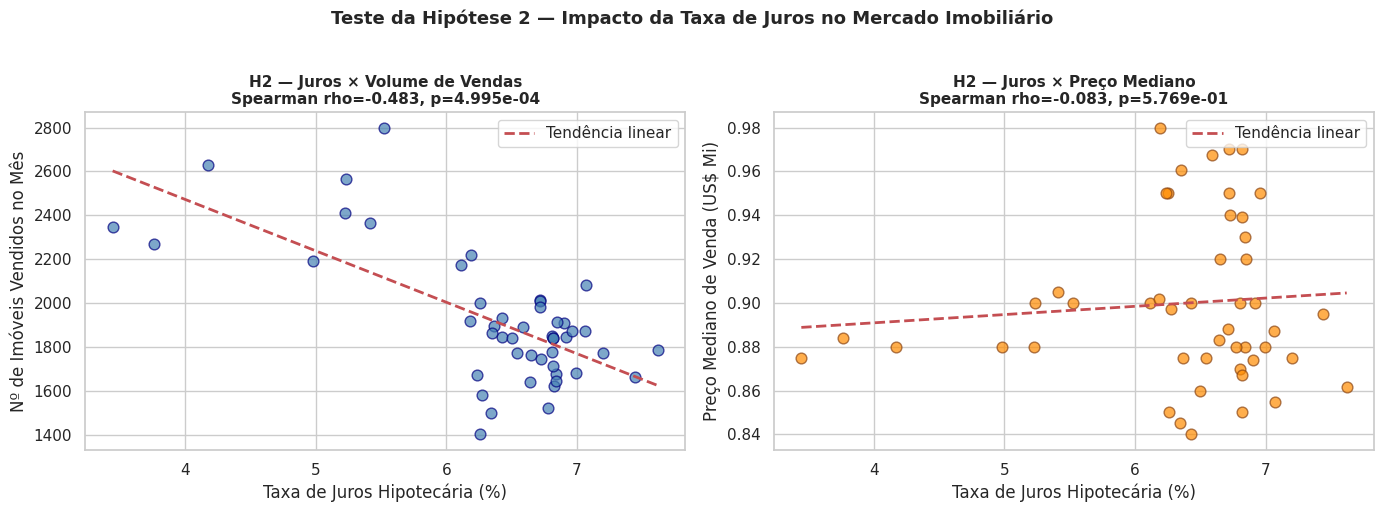

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(vendas_mensais['juros'], vendas_mensais['volume_vendas'],
                color='steelblue', alpha=0.7, edgecolors='navy', s=60)

#Linha de tendência
z = np.polyfit(vendas_mensais['juros'], vendas_mensais['volume_vendas'], 1)
p_line = np.poly1d(z)
x_range = np.linspace(vendas_mensais['juros'].min(), vendas_mensais['juros'].max(), 100)
axes[0].plot(x_range, p_line(x_range), 'r--', lw=2, label='Tendência linear')
axes[0].set_title(f'H2 — Juros × Volume de Vendas\nSpearman rho={r_vol:+.3f}, p={p_vol:.3e}',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Taxa de Juros Hipotecária (%)')
axes[0].set_ylabel('Nº de Imóveis Vendidos no Mês')
axes[0].legend()

axes[1].scatter(vendas_mensais['juros'], vendas_mensais['media_preco'] / 1e6,
                color='darkorange', alpha=0.7, edgecolors='saddlebrown', s=60)
z2 = np.polyfit(vendas_mensais['juros'], vendas_mensais['media_preco'] / 1e6, 1)
p_line2 = np.poly1d(z2)
axes[1].plot(x_range, p_line2(x_range), 'r--', lw=2, label='Tendência linear')
axes[1].set_title(f'H2 — Juros × Preço Mediano\nSpearman rho={r_preco:+.3f}, p={p_preco:.3e}',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Taxa de Juros Hipotecária (%)')
axes[1].set_ylabel('Preço Mediano de Venda (US$ Mi)')
axes[1].legend()

plt.suptitle('Teste da Hipótese 2 — Impacto da Taxa de Juros no Mercado Imobiliário',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Nesse teste confirmamos que o Juros afeta o volume mas não o preço. Isso ja era esperado, quando juros sobem, os compradores diminuem pois o financiamento fica inacessível. O preço não é esperado que mude, pois vendedores de imóveis preferem segurar o preço invés de abaixar, algo chamado de price stickiness.

####Agrupando bairros por mês

In [58]:
query_bairros = f"""
    SELECT
        CASE BOROUGH
            WHEN 1 THEN '1. Manhattan'
            WHEN 2 THEN '2. Bronx'
            WHEN 3 THEN '3. Brooklyn'
            WHEN 4 THEN '4. Queens'
            WHEN 5 THEN '5. Staten Island'
        END AS nome_bairro,
        sale_month,
        AVG(qtd_crimes_graves) AS media_crimes,
        COUNT(*) AS volume_vendas,
        SUM("SALE PRICE") / NULLIF(SUM("GROSS SQUARE FEET"), 0) AS preco_medio_sqft
    FROM '{path_parquet}'
    WHERE "SALE PRICE" > 10000
      AND "GROSS SQUARE FEET" > 100
    GROUP BY BOROUGH, sale_month
"""

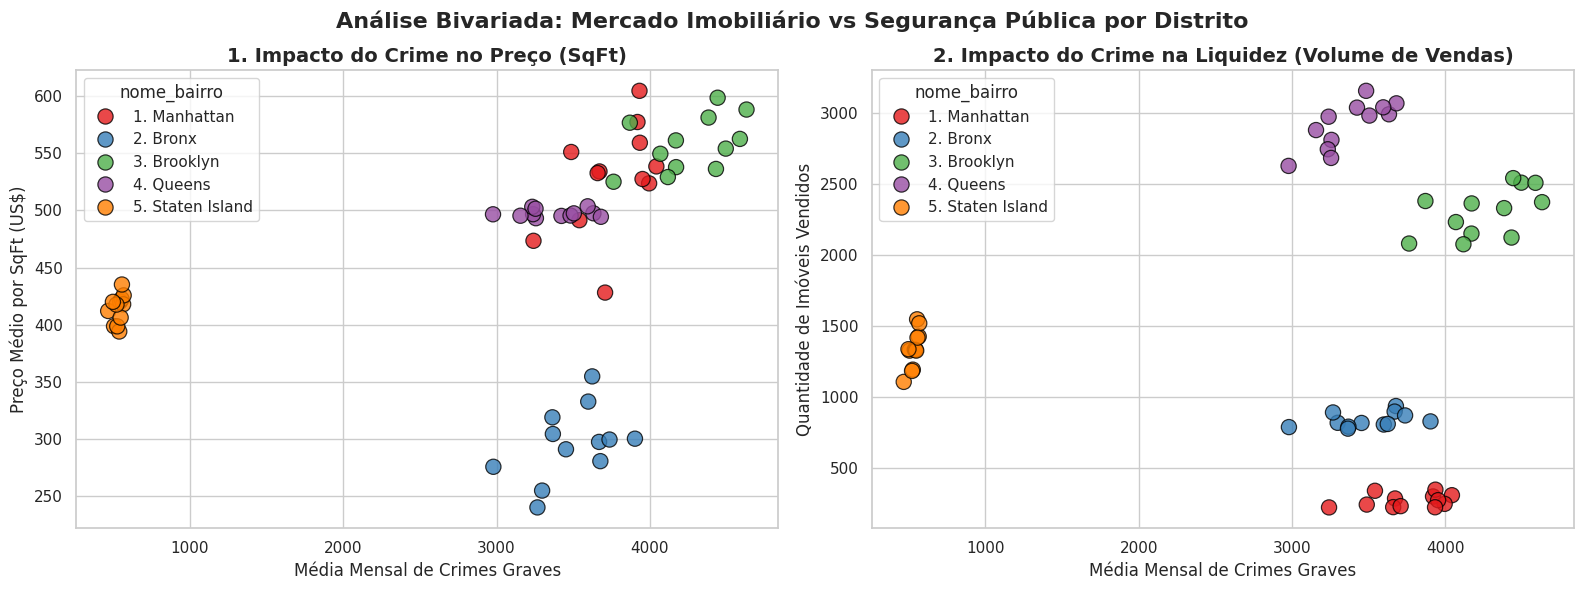

In [59]:
df_mercado_crime = con.execute(query_bairros).df()

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=df_mercado_crime,
    x='media_crimes',
    y='preco_medio_sqft',
    hue='nome_bairro',
    palette='Set1',
    s=120, alpha=0.8, edgecolor='black', ax=ax[0]
)
ax[0].set_title('1. Impacto do Crime no Preço (SqFt)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Média Mensal de Crimes Graves')
ax[0].set_ylabel('Preço Médio por SqFt (US$)')

sns.scatterplot(
    data=df_mercado_crime,
    x='media_crimes',
    y='volume_vendas',
    hue='nome_bairro',
    palette='Set1',
    s=120, alpha=0.8, edgecolor='black', ax=ax[1]
)
ax[1].set_title('2. Impacto do Crime na Liquidez (Volume de Vendas)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Média Mensal de Crimes Graves')
ax[1].set_ylabel('Quantidade de Imóveis Vendidos')

plt.tight_layout()
fig.subplots_adjust(top=0.88)
plt.suptitle('Análise Bivariada: Mercado Imobiliário vs Segurança Pública por Distrito', fontsize=16, fontweight='bold')
plt.show()

Esse gráfico é muito interessante pelo fato da liquidez ficar bem separada por distritos, podendo ser um otimo parâmetro pro modelo.

####H3 — Imunidade de Distritos com alta demanda ao Crime e Juros

In [60]:
query_h3 = f"""
    SELECT
        BOROUGH,
        sale_year,
        sale_month,
        AVG("SALE PRICE")                                           AS preco_medio,
        COUNT(*)                                                    AS volume_vendas,
        SUM("SALE PRICE") / NULLIF(SUM("GROSS SQUARE FEET"), 0)    AS preco_medio_sqft,
        AVG(qtd_crimes_graves + qtd_crimes_leves)                   AS crimes_total,
        AVG(media_juros_hipoteca)                                   AS juros
    FROM '{path_parquet}'
    WHERE "SALE PRICE" > 10000
      AND "GROSS SQUARE FEET" > 100
    GROUP BY BOROUGH, sale_year, sale_month
    ORDER BY BOROUGH, sale_year, sale_month
"""

In [61]:
df_h3 = con.execute(query_h3).df()

mapa_borough = {
    '1': 'Manhattan', '2': 'Bronx',   '3': 'Brooklyn',
    '4': 'Queens',    '5': 'Staten Island'
}
df_h3['distrito'] = df_h3['BOROUGH'].astype(str).str.strip().map(mapa_borough)
df_h3 = df_h3.dropna(subset=['distrito'])

print(f'Períodos por distrito: {df_h3.groupby("distrito").size().to_dict()}')
display(df_h3.head())

Períodos por distrito: {'Bronx': 48, 'Brooklyn': 48, 'Manhattan': 48, 'Queens': 48, 'Staten Island': 48}


,BOROUGH,sale_year,sale_month,preco_medio,volume_vendas,preco_medio_sqft,crimes_total,juros,distrito
0,1,2022,1,5.414162e+06,86,606.229089,8000.0,3.4450,Manhattan
1,1,2022,2,5.063101e+06,66,507.019150,8627.0,3.7625,Manhattan
2,1,2022,3,5.265206e+06,91,489.749582,9955.0,4.1720,Manhattan
3,1,2022,4,4.975051e+06,65,444.647477,9620.0,4.9825,Manhattan
4,1,2022,5,5.926407e+06,102,579.918874,10193.0,5.2300,Manhattan


In [62]:
resultados = []
for distrito, grupo in df_h3.groupby('distrito'):
    grupo = grupo.dropna(subset=['crimes_total', 'juros', 'preco_medio_sqft', 'volume_vendas'])

    r_crime, p_crime   = stats.spearmanr(grupo['crimes_total'],  grupo['preco_medio_sqft'])
    r_juros_p, p_jp    = stats.spearmanr(grupo['juros'],         grupo['preco_medio_sqft'])
    r_juros_v, p_jv    = stats.spearmanr(grupo['juros'],         grupo['volume_vendas'])
    preco_medio_geral  = grupo['preco_medio'].mean()

    resultados.append({
        'Distrito'               : distrito,
        'Preço Médio (US$)'      : preco_medio_geral,
        'rho Crime×Preço'        : round(r_crime,   3),
        'p Crime×Preço'          : round(p_crime,   4),
        'rho Juros×Preço'        : round(r_juros_p, 3),
        'p Juros×Preço'          : round(p_jp,      4),
        'rho Juros×Volume'       : round(r_juros_v, 3),
        'p Juros×Volume'         : round(p_jv,      4),
    })

df_res = pd.DataFrame(resultados).sort_values('Preço Médio (US$)', ascending=False)

# Classificar demanda
mediana_preco = df_res['Preço Médio (US$)'].median()
df_res['Demanda'] = df_res['Preço Médio (US$)'].apply(
    lambda x: 'Alta demanda' if x >= mediana_preco else 'Baixa demanda'
)

print('=== Correlações por Distrito ===')
display(
    df_res.style.format({
        'Preço Médio (US$)': '${:,.0f}',
        'rho Crime×Preço'  : '{:+.3f}',
        'rho Juros×Preço'  : '{:+.3f}',
        'rho Juros×Volume' : '{:+.3f}',
    }).background_gradient(
        subset=['rho Crime×Preço', 'rho Juros×Preço', 'rho Juros×Volume'],
        cmap='RdYlGn', vmin=-1, vmax=1
    )
)

=== Correlações por Distrito ===


,Distrito,Preço Médio (US$),rho Crime×Preço,p Crime×Preço,rho Juros×Preço,p Juros×Preço,rho Juros×Volume,p Juros×Volume,Demanda
2,Manhattan,"$5,171,631",+0.293,0.043500,-0.107,0.467600,-0.304,0.035400,Alta demanda
1,Brooklyn,"$1,700,710",+0.428,0.002400,-0.001,0.994200,-0.446,0.001500,Alta demanda
3,Queens,"$1,072,826",+0.136,0.355800,+0.085,0.564200,-0.430,0.002300,Alta demanda
0,Bronx,"$1,067,101",-0.090,0.544500,-0.038,0.799400,-0.522,0.000100,Baixa demanda
4,Staten Island,"$781,215",+0.022,0.880700,+0.146,0.322100,-0.447,0.001400,Baixa demanda


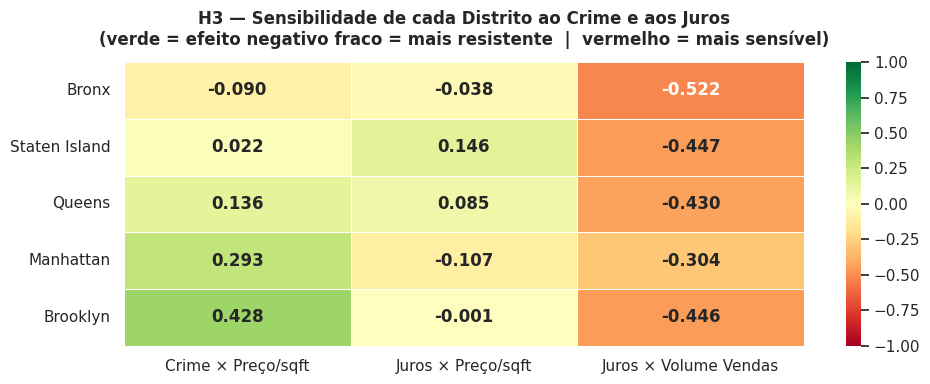

In [63]:
df_heat = df_res.set_index('Distrito')[['rho Crime×Preço', 'rho Juros×Preço', 'rho Juros×Volume']]
df_heat.columns = ['Crime × Preço/sqft', 'Juros × Preço/sqft', 'Juros × Volume Vendas']
df_heat = df_heat.sort_values('Crime × Preço/sqft')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    df_heat, annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 12, 'weight': 'bold'}, ax=ax
)
ax.set_title(
    'H3 — Sensibilidade de cada Distrito ao Crime e aos Juros\n'
    '(verde = efeito negativo fraco = mais resistente  |  vermelho = mais sensível)',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Bronx, State Island e Queens são considerados periferias, o Bronx sendo considerado o distrito com a renda per capita mais baixa e o metro quadrado mais acessível de NYC, analisando o teste conseguimos ver que esses distritos possuem uma maior sensibilidade à crimes e aos juros, estando de acordo com a H3. Brooklyn não pode ser mais considerado como periferia, pois sofreu uma gentrificação massiva, e Manhattan é considerado um polo de luxo e centro econômico, ademais podemos perceber que tanto brooklyn quanto Manhattan possuem uma maior resitência à crimes, e Manhattan uma maior resistência ao juros, demonstrando a força da demanda.
Como o teste foi feito usando o dado de crime agregado por borough, sabemos depois de discutir na H1 que existe uma confusão com densidade urbana. Porém, ainda conseguimos confirmar parcialmente a H3 por conta da resistência aos juros no volume de vendas, Manhattan perde menos volume de vendas quando os juros sobem, podendo indicar que os compradores de Manhattan têm maior capacidade de compra à vista ou acesso a financiamentos diferenciados, reduzindo a dependência da taxa hipotecária.

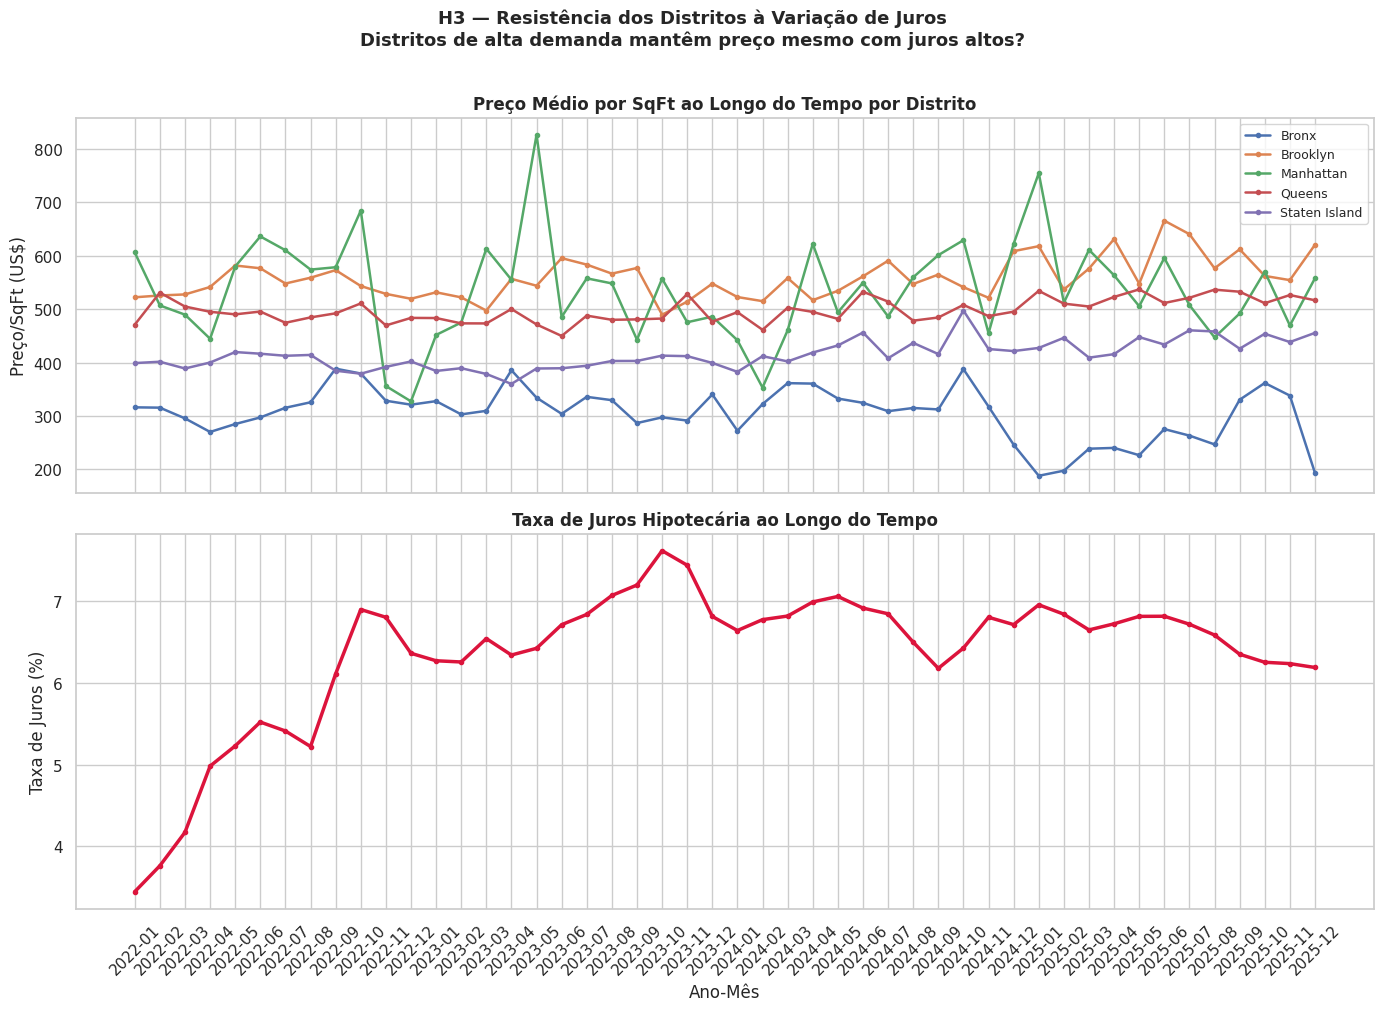

In [64]:
df_h3['ano_mes'] = df_h3['sale_year'].astype(str) + '-' + df_h3['sale_month'].astype(str).str.zfill(2)
df_h3_sorted = df_h3.sort_values('ano_mes')

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Preço médio por sqft por distrito ao longo do tempo
for distrito, grupo in df_h3_sorted.groupby('distrito'):
    axes[0].plot(grupo['ano_mes'], grupo['preco_medio_sqft'],
                 marker='o', markersize=3, linewidth=1.8, label=distrito)
axes[0].set_title('Preço Médio por SqFt ao Longo do Tempo por Distrito', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Preço/SqFt (US$)')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=45)

# Taxa de juros no mesmo eixo de tempo
juros_tempo = df_h3_sorted.groupby('ano_mes')['juros'].mean().reset_index()
axes[1].plot(juros_tempo['ano_mes'], juros_tempo['juros'],
             color='crimson', linewidth=2.5, marker='o', markersize=3)
axes[1].set_title('Taxa de Juros Hipotecária ao Longo do Tempo', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Taxa de Juros (%)')
axes[1].set_xlabel('Ano-Mês')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(
    'H3 — Resistência dos Distritos à Variação de Juros\n'
    'Distritos de alta demanda mantêm preço mesmo com juros altos?',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

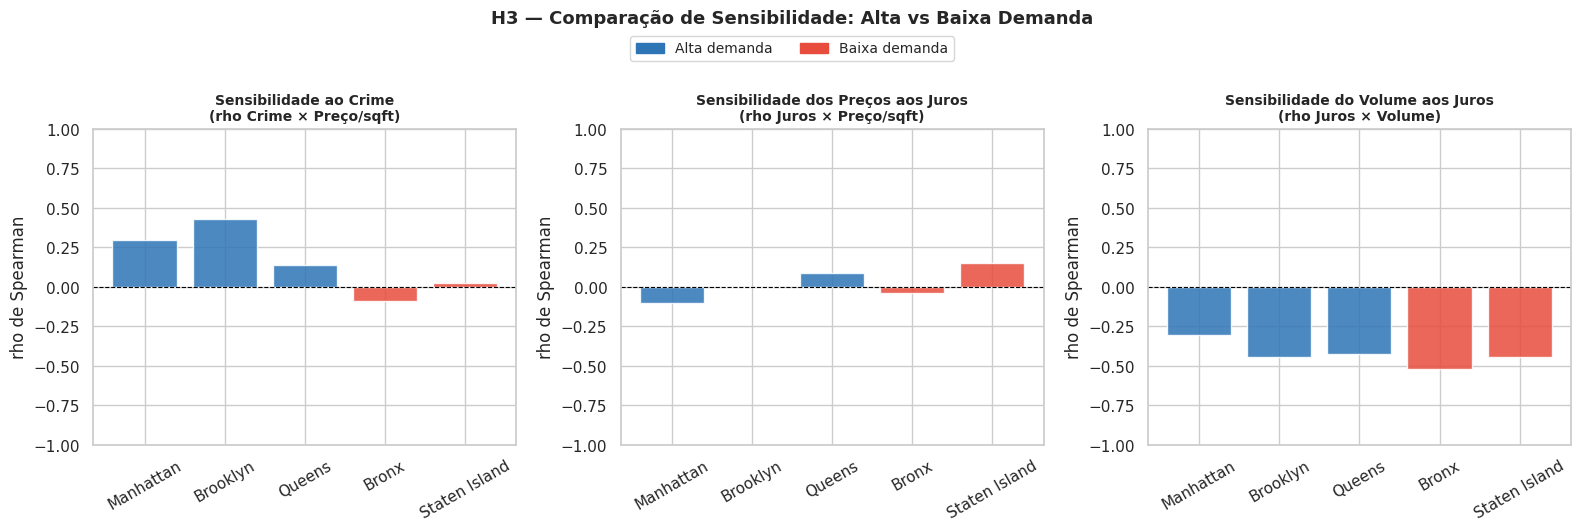

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metricas = [
    ('rho Crime×Preço',  'Sensibilidade ao Crime\n(rho Crime × Preço/sqft)'),
    ('rho Juros×Preço',  'Sensibilidade dos Preços aos Juros\n(rho Juros × Preço/sqft)'),
    ('rho Juros×Volume', 'Sensibilidade do Volume aos Juros\n(rho Juros × Volume)'),
]

cores = {'Alta demanda': '#2E75B6', 'Baixa demanda': '#e74c3c'}

for ax, (col, titulo) in zip(axes, metricas):
    for _, row in df_res.iterrows():
        cor = cores[row['Demanda']]
        ax.bar(row['Distrito'], row[col], color=cor, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_ylabel('rho de Spearman')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(-1, 1)

from matplotlib.patches import Patch
handles = [Patch(color=c, label=l) for l, c in cores.items()]
fig.legend(handles=handles, loc='upper center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.02))

plt.suptitle('H3 — Comparação de Sensibilidade: Alta vs Baixa Demanda',
             fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()

####Matriz de Correlação

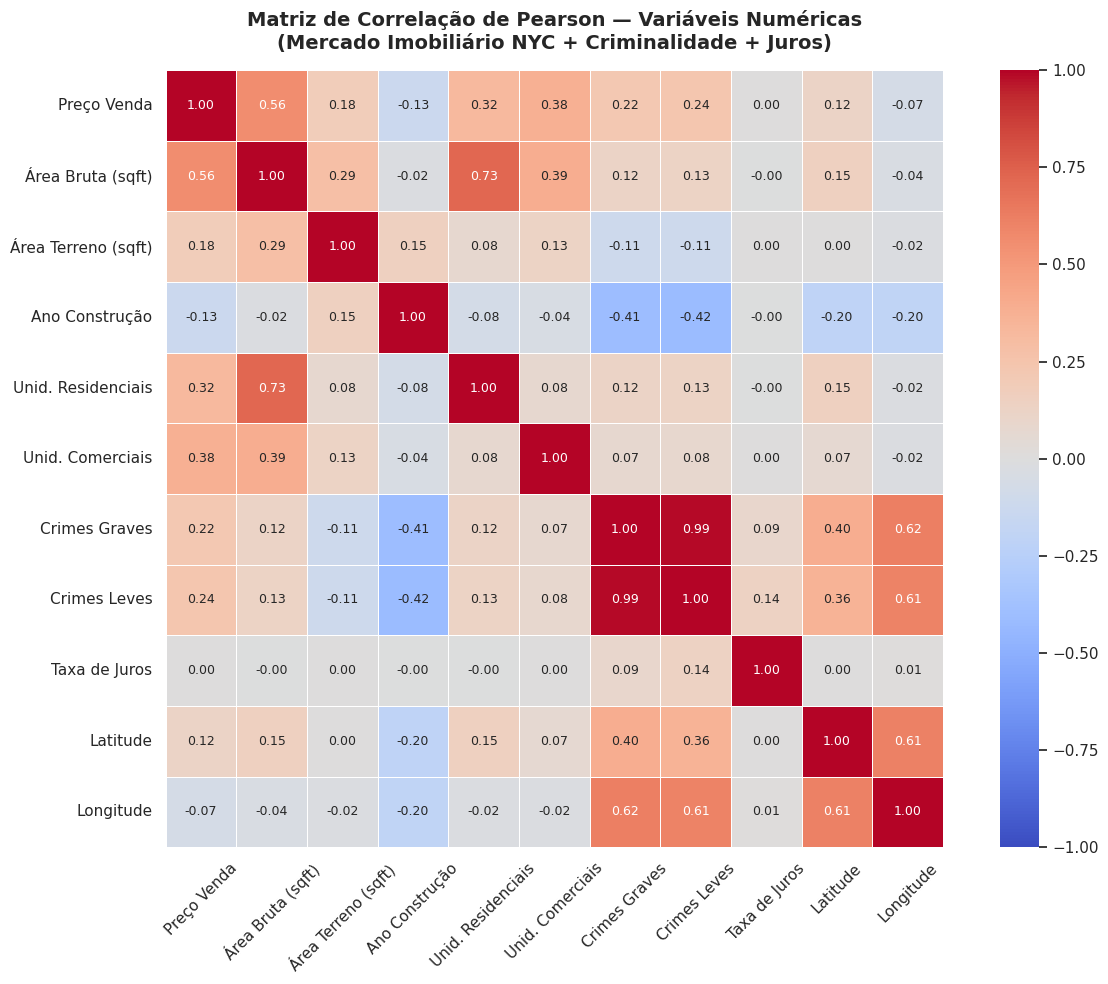


Correlações com Preço de Venda (ordenadas por força)
  Área Bruta (sqft)         r = +0.558  (↑ positiva)
  Unid. Comerciais          r = +0.382  (↑ positiva)
  Unid. Residenciais        r = +0.322  (↑ positiva)
  Crimes Leves              r = +0.236  (↑ positiva)
  Crimes Graves             r = +0.219  (↑ positiva)
  Área Terreno (sqft)       r = +0.181  (↑ positiva)
  Ano Construção            r = -0.127  (↓ negativa)
  Latitude                  r = +0.119  (↑ positiva)
  Longitude                 r = -0.068  (↓ negativa)
  Taxa de Juros             r = +0.001  (↑ positiva)


In [66]:
cols_corr = [
    'SALE PRICE',
    'GROSS SQUARE FEET',
    'LAND SQUARE FEET',
    'YEAR BUILT',
    'RESIDENTIAL UNITS',
    'COMMERCIAL UNITS',
    'qtd_crimes_graves',
    'qtd_crimes_leves',
    'media_juros_hipoteca',
    'Latitude',
    'Longitude'
]

df_corr = df_dataset_final[cols_corr].copy()

#Nomes mais legíveis para o heatmap
rename_map = {
    'SALE PRICE': 'Preço Venda',
    'GROSS SQUARE FEET': 'Área Bruta (sqft)',
    'LAND SQUARE FEET': 'Área Terreno (sqft)',
    'YEAR BUILT': 'Ano Construção',
    'RESIDENTIAL UNITS': 'Unid. Residenciais',
    'COMMERCIAL UNITS': 'Unid. Comerciais',
    'qtd_crimes_graves': 'Crimes Graves',
    'qtd_crimes_leves': 'Crimes Leves',
    'media_juros_hipoteca': 'Taxa de Juros',
    'Latitude': 'Latitude',
    'Longitude': 'Longitude'
}
df_corr = df_corr.rename(columns=rename_map)

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title(
    'Matriz de Correlação de Pearson — Variáveis Numéricas\n'
    '(Mercado Imobiliário NYC + Criminalidade + Juros)',
    fontsize=14, fontweight='bold', pad=15
)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

print('\nCorrelações com Preço de Venda (ordenadas por força)')
corr_preco = corr_matrix['Preço Venda'].drop('Preço Venda').sort_values(key=abs, ascending=False)
for var, val in corr_preco.items():
    direcao = '↑ positiva' if val > 0 else '↓ negativa'
    print(f'  {var:<25} r = {val:+.3f}  ({direcao})')

##Modelagem com Machine Learning

Como é um problema de regressão e quero prever o valor de imóveis, serão usados os seguintes modelos: Regressão linear, KNN, Random Forest e Xgboost. Alguns modelos foram desconsiderados por exigirem muito esforço da maquina.


###Implementação de Modelos

In [67]:
df = pd.read_parquet('dados/nyc_dados_finais_limpos_v2.parquet')
df_ml = df.copy()

####Algumas Features

In [68]:
for col in df_ml.select_dtypes(include='category').columns:
    df_ml[col] = df_ml[col].astype(str)

df_ml['age_at_sale'] = (df_ml['sale_year'] - df_ml['YEAR BUILT']).clip(lower=0)

total_crimes = df_ml['qtd_crimes_graves'] + df_ml['qtd_crimes_leves']
df_ml['crimes_ratio'] = df_ml['qtd_crimes_graves'] / total_crimes.replace(0, float('nan'))

df_ml['sqft_ratio'] = df_ml['GROSS SQUARE FEET'] / df_ml['LAND SQUARE FEET'].replace(0, float('nan'))
df_ml['sqft_ratio'] = df_ml['sqft_ratio'].fillna(0)
df_ml['sqft_ratio'] = df_ml['sqft_ratio'].clip(upper=df_ml['sqft_ratio'].quantile(0.99))

df_ml['price_log'] = np.log1p(df_ml['SALE PRICE'])

print(f'\nDistribuição original do SALE PRICE:')
print(df_ml['SALE PRICE'].describe())
print(f'\nDistribuição log-transformada (price_log):')
print(df_ml['price_log'].describe())


Distribuição original do SALE PRICE:
count    9.210300e+04
mean     1.359696e+06
std      1.520827e+06
min      1.031400e+04
25%      6.700000e+05
50%      9.000000e+05
75%      1.339606e+06
max      8.779497e+06
Name: SALE PRICE, dtype: float64

Distribuição log-transformada (price_log):
count    92103.000000
mean        13.800450
std          0.751782
min          9.241354
25%         13.415034
50%         13.710151
75%         14.107887
max         15.987930
Name: price_log, dtype: float64


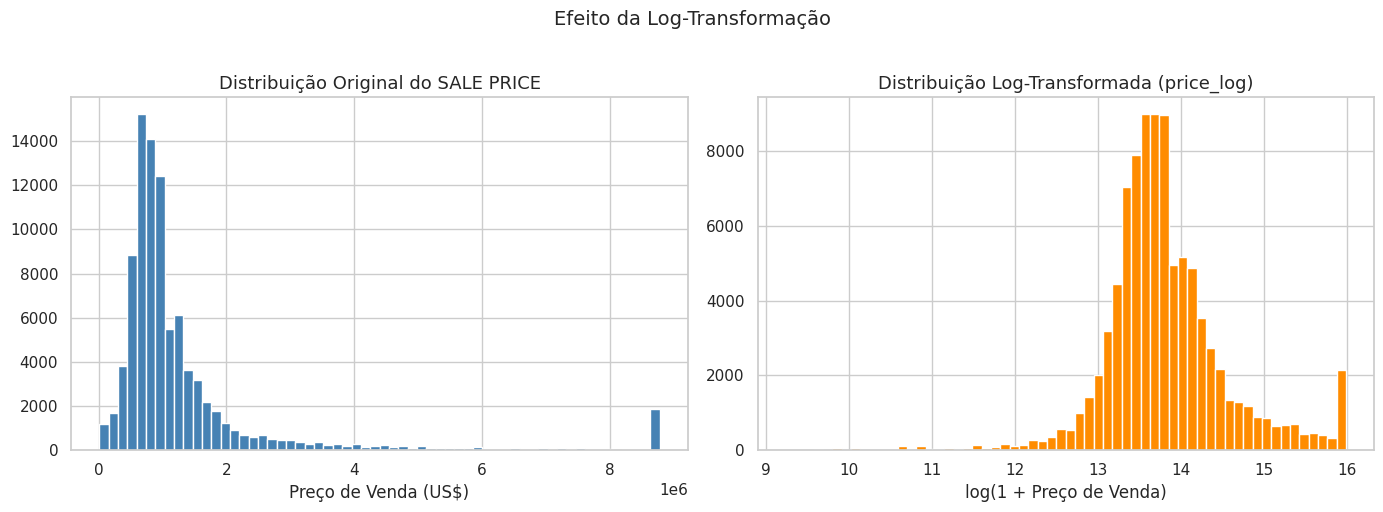

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap = df_ml['SALE PRICE'].quantile(0.99)
axes[0].hist(df_ml['SALE PRICE'].clip(upper=cap), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição Original do SALE PRICE', fontsize=13)
axes[0].set_xlabel('Preço de Venda (US$)')

axes[1].hist(df_ml['price_log'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Distribuição Log-Transformada (price_log)', fontsize=13)
axes[1].set_xlabel('log(1 + Preço de Venda)')
#Aplicar a transformação logarítmica (\(\log(y)\)) estabiliza a variância e força o modelo a aprender erros percentuais proporcionais, e não absolutos.
plt.suptitle('Efeito da Log-Transformação', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [70]:
FEATURES_NUM = [
    'BOROUGH', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS',
    'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT',
    'Latitude', 'Longitude',
    'qtd_crimes_graves', 'qtd_crimes_leves', 'media_juros_hipoteca',
    'sale_year', 'sale_month', 'sale_day_of_week',
    'age_at_sale', 'crimes_ratio', 'sqft_ratio'
]

FEATURES_TARGET_ENC = ['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY']

df_ml['TAX_CLASS_NUM'] = pd.to_numeric(
    df_ml['TAX CLASS AT TIME OF SALE'].astype(str).str.extract(r'(\d)')[0])
FEATURES_NUM.append('TAX_CLASS_NUM')

FEATURES_ALL = FEATURES_NUM + FEATURES_TARGET_ENC
TARGET = 'price_log'

df_clean = df_ml[FEATURES_ALL + [TARGET, 'SALE PRICE']].copy()
print(f'Dataset para modelagem: {df_clean.shape}')
print(f'Features numéricas    : {len(FEATURES_NUM)}')
print(f'Features Target Enc.  : {len(FEATURES_TARGET_ENC)}')

Dataset para modelagem: (92103, 23)
Features numéricas    : 19
Features Target Enc.  : 2


#####Refazendo a mesma analise para checar a eficacia da feature 'crimes_ratio'

In [71]:
query_ratio = """
    SELECT
        CASE BOROUGH
            WHEN 1 THEN '1. Manhattan'
            WHEN 2 THEN '2. Bronx'
            WHEN 3 THEN '3. Brooklyn'
            WHEN 4 THEN '4. Queens'
            WHEN 5 THEN '5. Staten Island'
        END AS nome_bairro,
        sale_month,
        AVG(crimes_ratio) AS media_crimes_ratio,
        COUNT(*) AS volume_vendas,
        SUM("SALE PRICE") / NULLIF(SUM("GROSS SQUARE FEET"), 0) AS preco_medio_sqft
    FROM df_ml
    WHERE "SALE PRICE" > 10000
      AND "GROSS SQUARE FEET" > 100
    GROUP BY BOROUGH, sale_month
"""

df_ratio_agg = duckdb.query(query_ratio).df()

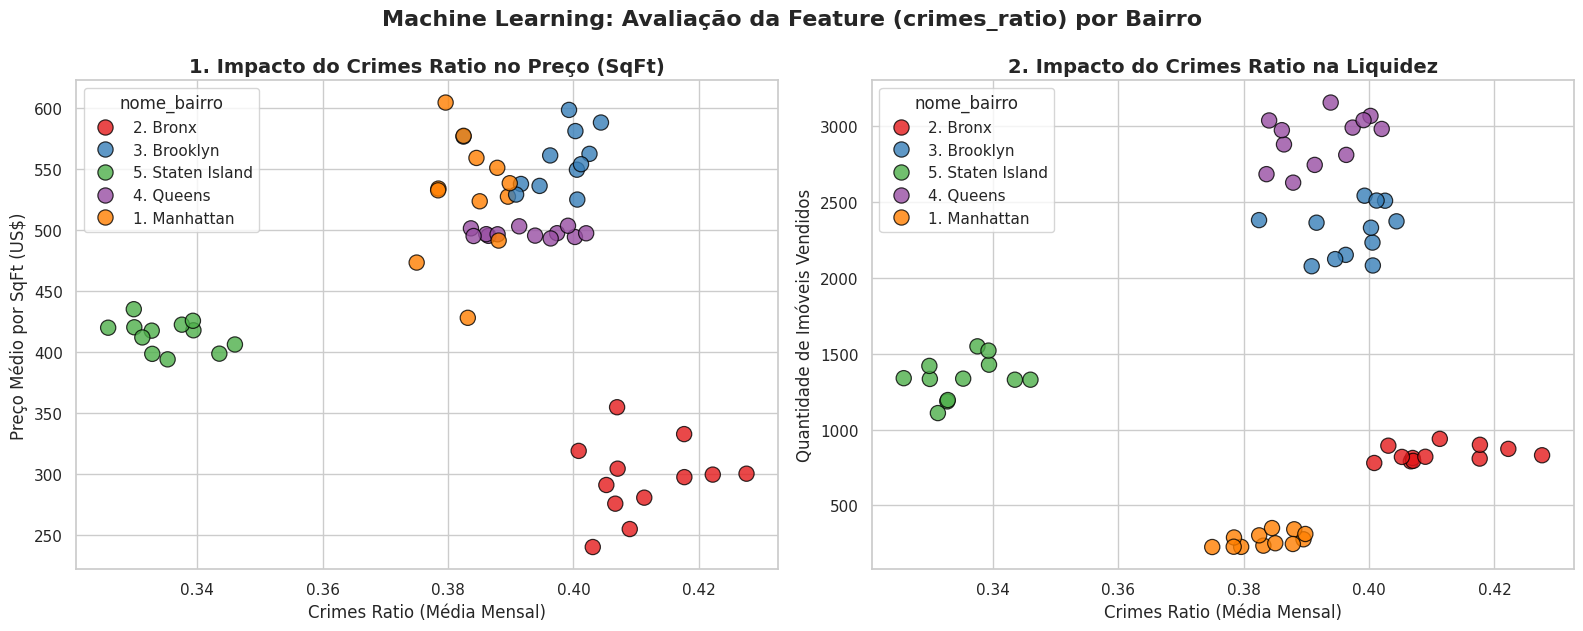

In [72]:
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

#Crimes Ratio vs. Preço do Metro Quadrado
sns.scatterplot(
    data=df_ratio_agg,
    x='media_crimes_ratio',
    y='preco_medio_sqft',
    hue='nome_bairro',
    palette='Set1',
    s=120, alpha=0.8, edgecolor='black', ax=ax[0]
)
ax[0].set_title('1. Impacto do Crimes Ratio no Preço (SqFt)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Crimes Ratio (Média Mensal)')
ax[0].set_ylabel('Preço Médio por SqFt (US$)')

#Crimes Ratio vs. Volume de Vendas
sns.scatterplot(
    data=df_ratio_agg,
    x='media_crimes_ratio',
    y='volume_vendas',
    hue='nome_bairro',
    palette='Set1',
    s=120, alpha=0.8, edgecolor='black', ax=ax[1]
)
ax[1].set_title('2. Impacto do Crimes Ratio na Liquidez', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Crimes Ratio (Média Mensal)')
ax[1].set_ylabel('Quantidade de Imóveis Vendidos')

plt.tight_layout()
plt.suptitle('Machine Learning: Avaliação da Feature (crimes_ratio) por Bairro', fontsize=16, fontweight='bold', y=1.05)
plt.show()

In [73]:
df_ratio_agg['faixa_risco_crime'] = pd.qcut(
    df_ratio_agg['media_crimes_ratio'],
    q=3,
    labels=['Rácio Baixo (Mais Seguro)', 'Rácio Médio', 'Rácio Alto (Mais Severo)']
)

analise_liquidez = df_ratio_agg.groupby('faixa_risco_crime').agg(
    total_imoveis_vendidos=('volume_vendas', 'sum'),
    media_vendas_por_bairro=('volume_vendas', 'mean'),
    quantidade_de_bairros=('nome_bairro', 'count'),
    exemplos_de_bairros=('nome_bairro', lambda x: ', '.join(list(x)[:3]))
).reset_index()

print("ANÁLISE QUANTITATIVA DA SEPARAÇÃO DA LIQUIDEZ")
print(analise_liquidez.to_string(index=False))

ANÁLISE QUANTITATIVA DA SEPARAÇÃO DA LIQUIDEZ
        faixa_risco_crime  total_imoveis_vendidos  media_vendas_por_bairro  quantidade_de_bairros                             exemplos_de_bairros
Rácio Baixo (Mais Seguro)                   22648                  1132.40                     20 3. Brooklyn, 5. Staten Island, 5. Staten Island
              Rácio Médio                   39302                  1965.10                     20           3. Brooklyn, 3. Brooklyn, 3. Brooklyn
 Rácio Alto (Mais Severo)                   30153                  1507.65                     20                    2. Bronx, 2. Bronx, 2. Bronx


/tmp/ipykernel_8094/632532809.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analise_liquidez = df_ratio_agg.groupby('faixa_risco_crime').agg(


####Funções Auxiliares

In [74]:
def evaluate_model(name, y_true_log, y_pred_log, y_true_orig):
    """Avalia o modelo em escala log e converte métricas para US$ (escala original)."""
    y_pred_orig = np.expm1(y_pred_log)
    rmse_orig = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae_orig  = mean_absolute_error(y_true_orig, y_pred_orig)
    r2        = r2_score(y_true_log, y_pred_log)
    safe_orig = np.where(y_true_orig == 0, float('nan'), y_true_orig)
    mape = float(np.nanmean(np.abs((y_true_orig - y_pred_orig) / safe_orig)) * 100)

    print(f'\n{"="*52}')
    print(f'  Modelo: {name}')
    print(f'  R²         : {r2:.4f}')
    print(f'  RMSE (US$) : ${rmse_orig:,.0f}')
    print(f'  MAE  (US$) : ${mae_orig:,.0f}')
    print(f'  MAPE (%)   : {mape:.2f}%')
    return {'modelo': name, 'R2': round(r2, 4),
            'RMSE': round(rmse_orig, 0), 'MAE': round(mae_orig, 0), 'MAPE': round(mape, 2)}

resultados = []

problema do one-hot enconding, Lembrar: calcula no treino e aplica no teste

In [75]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    """Target Encoding com suavização Bayesiana para variáveis de alta cardinalidade."""
    def __init__(self, cols, smoothing=30):
        self.cols = cols
        self.smoothing = smoothing
        self.global_mean_ = None
        self.maps_ = {}

    def fit(self, X, y):
        df_temp = X[self.cols].copy()
        df_temp['__target__'] = y.values
        self.global_mean_ = float(y.mean())
        for col in self.cols:
            stats = df_temp.groupby(col)['__target__'].agg(['mean', 'count'])
            smoother = stats['count'] / (stats['count'] + self.smoothing)
            self.maps_[col] = smoother * stats['mean'] + (1 - smoother) * self.global_mean_
        return self

    def transform(self, X):
        X_out = X.copy()
        for col in self.cols:
            X_out[col] = X_out[col].map(self.maps_[col]).fillna(self.global_mean_)
        return X_out

print('Classe TargetEncoder definida.')

Classe TargetEncoder definida.


####Divisão treino e teste

In [76]:
X = df_clean[FEATURES_ALL].copy()
y = df_clean[TARGET].copy()
y_original = df_clean['SALE PRICE'].copy()

X_train, X_test, y_train, y_test, y_train_orig, y_test_orig = train_test_split(
    X, y, y_original, test_size=0.2, random_state=42
)

print(f'Treino : {X_train.shape[0]:,} amostras')
print(f'Teste  : {X_test.shape[0]:,} amostras')

te = TargetEncoder(cols=FEATURES_TARGET_ENC, smoothing=30)
X_train = te.fit_transform(X_train, y_train)
X_test  = te.transform(X_test)

X_train = X_train.astype(float)
X_test  = X_test.astype(float)

print('Divisão e Target Encoding concluídos!')

Treino : 73,682 amostras
Teste  : 18,421 amostras
Divisão e Target Encoding concluídos!


####Modelo Baseline

Chutando usando a mediana de todos os imóveis

In [77]:
y_pred_baseline = np.full(len(y_test), float(y_train.median()))
res_baseline = evaluate_model('Baseline (Mediana)', y_test.values, y_pred_baseline, y_test_orig.values)
resultados.append(res_baseline)


  Modelo: Baseline (Mediana)
  R²         : -0.0140
  RMSE (US$) : $1,562,923
  MAE  (US$) : $711,475
  MAPE (%)   : 68.22%


####Regressão Linear - Ridge

In [78]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge(alpha=1.0))
])

pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

res_lr = evaluate_model('Regressão Ridge', y_test.values, y_pred_lr, y_test_orig.values)
resultados.append(res_lr)


  Modelo: Regressão Ridge
  R²         : 0.4915
  RMSE (US$) : $1,151,526
  MAE  (US$) : $468,766
  MAPE (%)   : 63.61%


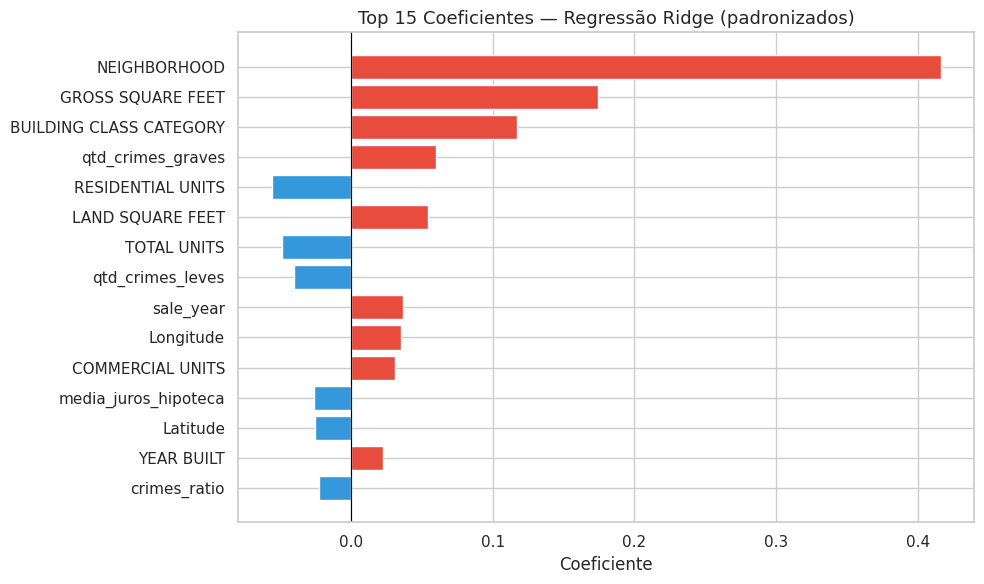

Azul = efeito negativo | Vermelho = efeito positivo no preço


In [79]:
coef_df = pd.DataFrame({
    'Feature': FEATURES_ALL,
    'Coeficiente': pipeline_lr.named_steps['ridge'].coef_
}).sort_values('Coeficiente', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coeficiente']]
plt.barh(coef_df['Feature'], coef_df['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Coeficientes — Regressão Ridge (padronizados)', fontsize=13)
plt.xlabel('Coeficiente')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print('Azul = efeito negativo | Vermelho = efeito positivo no preço')

####Random Forest

In [80]:
rf_base = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_base.fit(X_train, y_train)
y_pred_rf = rf_base.predict(X_test)

res_rf = evaluate_model('Random Forest (v1 — sem tuning)', y_test.values, y_pred_rf, y_test_orig.values)
resultados.append(res_rf)


  Modelo: Random Forest (v1 — sem tuning)
  R²         : 0.6124
  RMSE (US$) : $779,681
  MAE  (US$) : $357,776
  MAPE (%)   : 51.62%


####XGBoost

In [81]:
xgb_base = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

xgb_base.fit(X_train, y_train)
y_pred_xgb = xgb_base.predict(X_test)

res_xgb = evaluate_model('XGBoost (v1 — sem tuning)', y_test.values, y_pred_xgb, y_test_orig.values)
resultados.append(res_xgb)


  Modelo: XGBoost (v1 — sem tuning)
  R²         : 0.6142
  RMSE (US$) : $789,457
  MAE  (US$) : $357,455
  MAPE (%)   : 51.40%


####Análise

Resultados — Antes do Tuning:


,modelo,R2,RMSE,MAE,MAPE
0,XGBoost (v1 — sem tuning),0.6142,789457.0,357455.0,51.40
1,Random Forest (v1 — sem tuning),0.6124,779681.0,357776.0,51.62
2,Regressão Ridge,0.4915,1151526.0,468766.0,63.61
3,Baseline (Mediana),-0.0140,1562923.0,711475.0,68.22


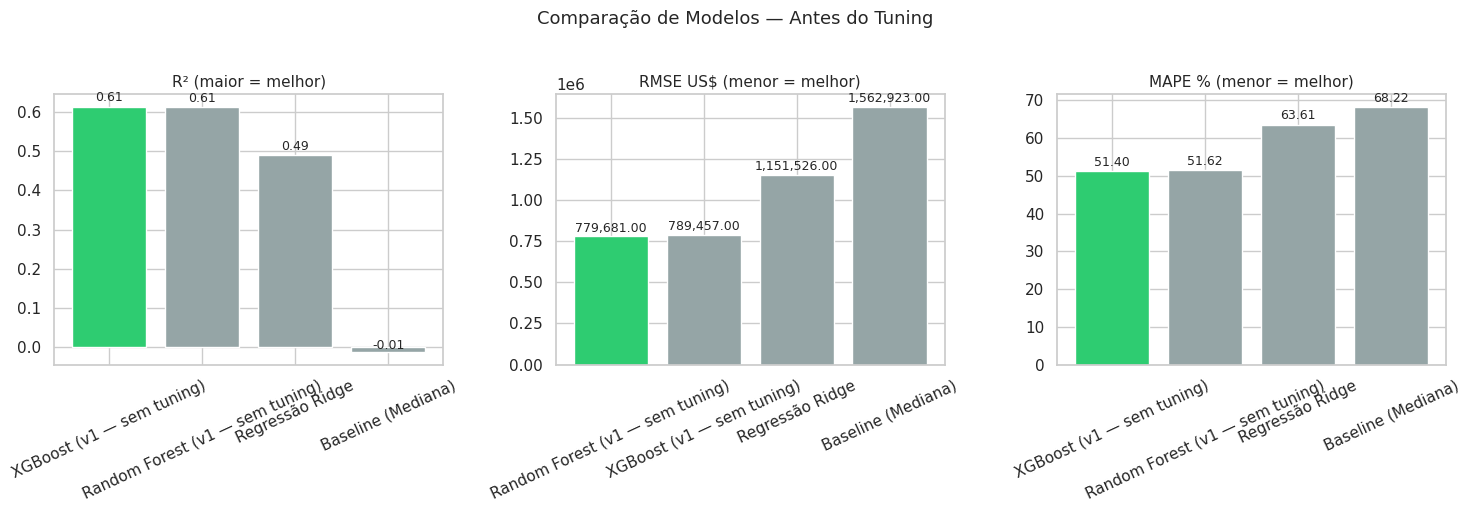

In [82]:
df_v1 = pd.DataFrame(resultados)
print('Resultados — Antes do Tuning:')
display(df_v1.sort_values('R2', ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_list = [('R2','R² (maior = melhor)',True), ('RMSE','RMSE US$ (menor = melhor)',False), ('MAPE','MAPE % (menor = melhor)',False)]

for ax, (metric, label, hb) in zip(axes, metrics_list):
    data = df_v1.sort_values(metric, ascending=not hb)
    bars = ax.bar(data['modelo'], data[metric],
                  color=['#2ecc71' if i==0 else '#95a5a6' for i in range(len(data))])
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, data[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:,.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparação de Modelos — Antes do Tuning', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Terceira onde de remoção de outlier

####K-Folds

In [83]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)


####Tuning do Random Forest

In [84]:
param_dist_rf = {
    'n_estimators'    : [100, 200, 300, 500],
    'max_depth'       : [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4, 8],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2', 0.5]
}

rs_rf = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=param_dist_rf,
    n_iter=30, scoring='r2', cv=kf,
    random_state=42, n_jobs=-1, verbose=1
)

rs_rf.fit(X_train, y_train)
print(f'\nMelhores parâmetros RF: {rs_rf.best_params_}')
print(f'Melhor R² (CV treino) : {rs_rf.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Melhores parâmetros RF: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Melhor R² (CV treino) : 0.6244


In [85]:
y_pred_rf_tuned = rs_rf.best_estimator_.predict(X_test)
res_rf_tuned = evaluate_model('Random Forest (v2 — pós-tuning)', y_test.values, y_pred_rf_tuned, y_test_orig.values)
resultados.append(res_rf_tuned)


  Modelo: Random Forest (v2 — pós-tuning)
  R²         : 0.6252
  RMSE (US$) : $777,100
  MAE  (US$) : $356,136
  MAPE (%)   : 50.46%


####Tuning do XGBoost

In [86]:
param_dist_xgb = {
    'n_estimators'    : [200, 400, 600],
    'max_depth'       : [4, 5, 6, 7, 8],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.15],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'reg_alpha'       : [0, 0.1, 0.5, 1.0],
    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0],
    'min_child_weight': [1, 3, 5]
}

rs_xgb = RandomizedSearchCV(
    xgb.XGBRegressor(n_jobs=-1, random_state=42, verbosity=0),
    param_distributions=param_dist_xgb,
    n_iter=40, scoring='r2', cv=kf,
    random_state=42, n_jobs=-1, verbose=1
)

rs_xgb.fit(X_train, y_train)
print(f'\nMelhores parâmetros XGB: {rs_xgb.best_params_}')
print(f'Melhor R² (CV treino)  : {rs_xgb.best_score_:.4f}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores parâmetros XGB: {'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Melhor R² (CV treino)  : 0.6250


In [87]:
y_pred_xgb_tuned = rs_xgb.best_estimator_.predict(X_test)
res_xgb_tuned = evaluate_model('XGBoost (v2 — pós-tuning)', y_test.values, y_pred_xgb_tuned, y_test_orig.values)
resultados.append(res_xgb_tuned)


  Modelo: XGBoost (v2 — pós-tuning)
  R²         : 0.6215
  RMSE (US$) : $772,358
  MAE  (US$) : $351,304
  MAPE (%)   : 51.02%


####Análise

Importância das Features do modelo XGBoost

/tmp/ipykernel_8094/35292963.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


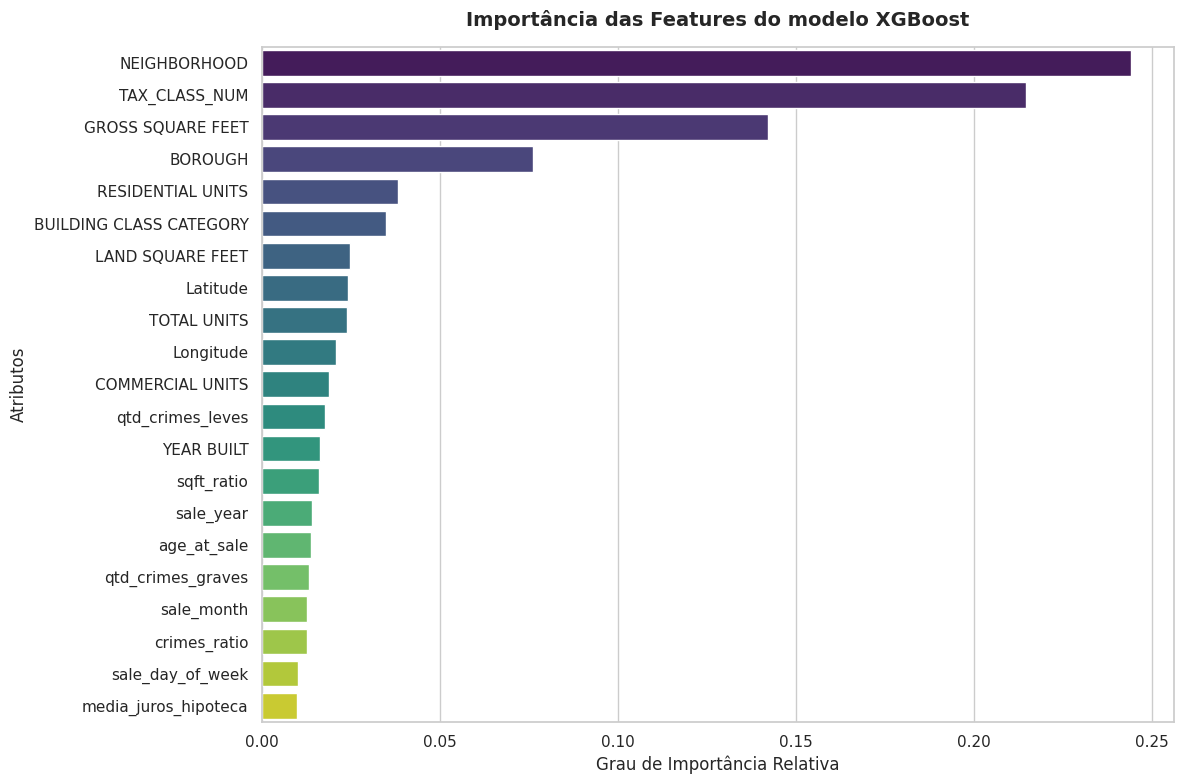


Tabela de Importância das Features:
               Atributo  Importancia
           NEIGHBORHOOD     0.244002
          TAX_CLASS_NUM     0.214655
      GROSS SQUARE FEET     0.142215
                BOROUGH     0.076227
      RESIDENTIAL UNITS     0.038358
BUILDING CLASS CATEGORY     0.034957
       LAND SQUARE FEET     0.024765
               Latitude     0.024167
            TOTAL UNITS     0.024080
              Longitude     0.020722
       COMMERCIAL UNITS     0.018895
       qtd_crimes_leves     0.017856
             YEAR BUILT     0.016470
             sqft_ratio     0.016039
              sale_year     0.014004
            age_at_sale     0.013776
      qtd_crimes_graves     0.013334
             sale_month     0.012743
           crimes_ratio     0.012594
       sale_day_of_week     0.010203
   media_juros_hipoteca     0.009941


In [88]:
melhor_xgb = rs_xgb.best_estimator_

importancias_xgb = melhor_xgb.feature_importances_

df_importancias_xgb = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importancia': importancias_xgb
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Importancia',
    y='Atributo',
    data=df_importancias_xgb,
    palette='viridis'
)

plt.title('Importância das Features do modelo XGBoost', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Grau de Importância Relativa', fontsize=12)
plt.ylabel('Atributos', fontsize=12)

plt.tight_layout()
plt.show()

print("\nTabela de Importância das Features:")
print(df_importancias_xgb.to_string(index=False))

Tabela Final de Resultados — Etapa 4


,modelo,R2,RMSE,MAE,MAPE
0,Random Forest (v2 — pós-tuning),0.6252,777100.0,356136.0,50.46
1,XGBoost (v2 — pós-tuning),0.6215,772358.0,351304.0,51.02
2,XGBoost (v1 — sem tuning),0.6142,789457.0,357455.0,51.40
3,Random Forest (v1 — sem tuning),0.6124,779681.0,357776.0,51.62
4,Regressão Ridge,0.4915,1151526.0,468766.0,63.61
5,Baseline (Mediana),-0.0140,1562923.0,711475.0,68.22


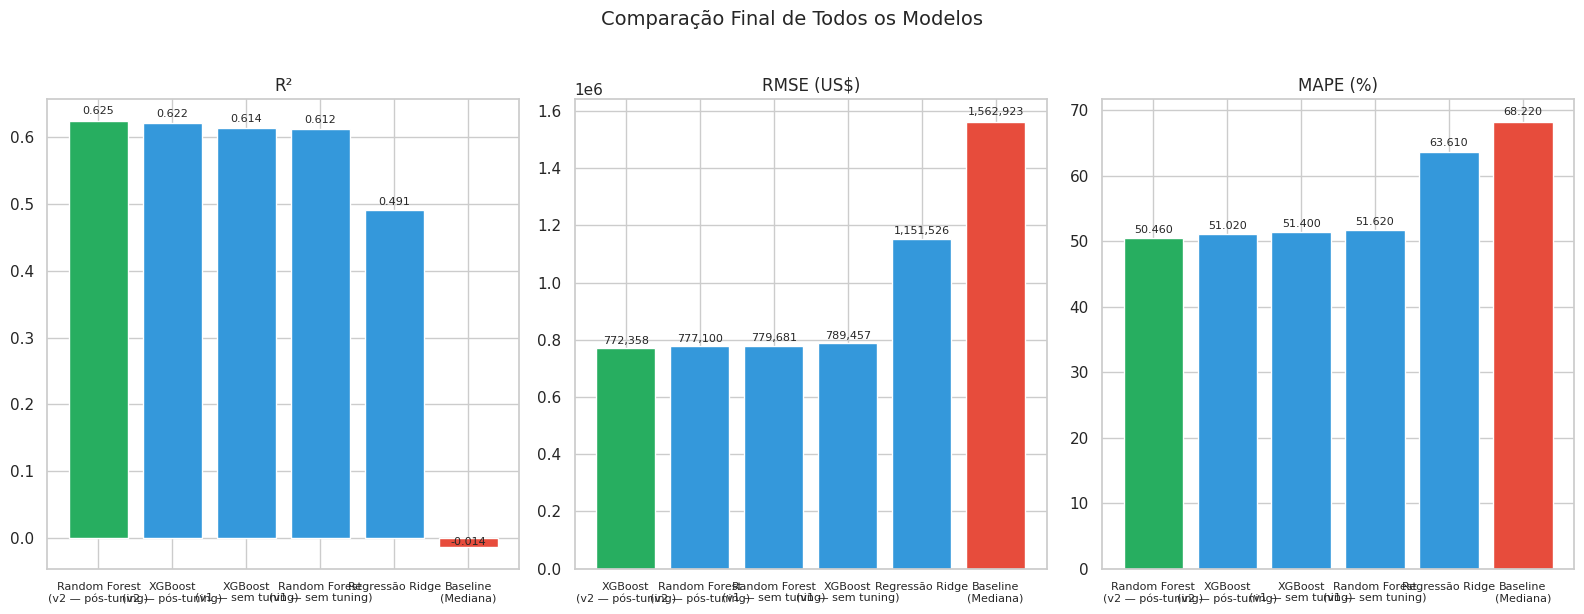

In [89]:
df_final = pd.DataFrame(resultados).sort_values('R2', ascending=False).reset_index(drop=True)
print('=' * 70)
print('Tabela Final de Resultados — Etapa 4')
print('=' * 70)
display(df_final)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, (metric, label, hb) in zip(axes, [('R2','R²',True),('RMSE','RMSE (US$)',False),('MAPE','MAPE (%)',False)]):
    data = df_final.sort_values(metric, ascending=not hb)
    colors_bar = ['#27ae60' if i==0 else '#e74c3c' if 'Baseline' in m else '#3498db'
                  for i, m in enumerate(data['modelo'])]
    bars = ax.bar(range(len(data)), data[metric], color=colors_bar)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels([m.replace(' (', '\n(') for m in data['modelo']], fontsize=8)
    ax.set_title(label, fontsize=12)
    for bar, val in zip(bars, data[metric]):
        lbl = f'{val:,.0f}' if metric in ['RMSE','MAE'] else f'{val:.3f}'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                lbl, ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparação Final de Todos os Modelos', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [90]:
comparacao_tuning = pd.DataFrame([
    {'Modelo': 'Random Forest',
     'R2 Antes': res_rf['R2'],     'R2 Depois': res_rf_tuned['R2'],
     'RMSE Antes': res_rf['RMSE'], 'RMSE Depois': res_rf_tuned['RMSE']},
    {'Modelo': 'XGBoost',
     'R2 Antes': res_xgb['R2'],     'R2 Depois': res_xgb_tuned['R2'],
     'RMSE Antes': res_xgb['RMSE'], 'RMSE Depois': res_xgb_tuned['RMSE']},
])
comparacao_tuning['Delta R2']   = (comparacao_tuning['R2 Depois']   - comparacao_tuning['R2 Antes']).round(4)
comparacao_tuning['Delta RMSE'] = (comparacao_tuning['RMSE Depois'] - comparacao_tuning['RMSE Antes']).round(0)
print('Impacto do Tuning de Hiperparâmetros:')
display(comparacao_tuning)

Impacto do Tuning de Hiperparâmetros:


,Modelo,R2 Antes,R2 Depois,RMSE Antes,RMSE Depois,Delta R2,Delta RMSE
0,Random Forest,0.6124,0.6252,779681.0,777100.0,0.0128,-2581.0
1,XGBoost,0.6142,0.6215,789457.0,772358.0,0.0073,-17099.0


####Análise de interpretabilidade vs. performance

####Melhor modelo

In [92]:
best_model = rs_xgb.best_estimator_

# Validação cruzada 5-fold APENAS sobre o treino — teste nunca visto
cv_scores = cross_val_score(best_model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

print('Validação Cruzada 5-Fold — XGBoost (tuned) — conjunto de TREINO:')
print(f'  Folds R²  : {[round(s,4) for s in cv_scores]}')
print(f'  Média     : {cv_scores.mean():.4f}')
print(f'  Desvio    : {cv_scores.std():.4f}')

print('\n' + '='*52)
print('Performance FINAL — conjunto de TESTE (hold-out 20%):')
evaluate_model('XGBoost (Final — hold-out)', y_test.values, y_pred_xgb_tuned, y_test_orig.values)

r2_test_final = r2_score(y_test.values, y_pred_xgb_tuned)
gap = abs(cv_scores.mean() - r2_test_final)
print(f'\nMonitoramento de overfitting:')
print(f'  R² médio CV    : {cv_scores.mean():.4f}')
print(f'  R² no teste    : {r2_test_final:.4f}')
print(f'  Gap (CV-Teste) : {gap:.4f}  {"OK" if gap < 0.02 else "ATENÇÃO — gap elevado"}')

Validação Cruzada 5-Fold — XGBoost (tuned) — conjunto de TREINO:
  Folds R²  : [np.float64(0.6557), np.float64(0.6353), np.float64(0.5953), np.float64(0.6152), np.float64(0.6233)]
  Média     : 0.6250
  Desvio    : 0.0202

Performance FINAL — conjunto de TESTE (hold-out 20%):

  Modelo: XGBoost (Final — hold-out)
  R²         : 0.6215
  RMSE (US$) : $772,358
  MAE  (US$) : $351,304
  MAPE (%)   : 51.02%

Monitoramento de overfitting:
  R² médio CV    : 0.6250
  R² no teste    : 0.6215
  Gap (CV-Teste) : 0.0035  OK


####Limitações

**1. Granularidade geográfica da criminalidade**  
Os dados de crimes foram agregados no nível de *borough* e depois integrados ao dataset de vendas. Isso significa que **todos os imóveis de Manhattan recebem o mesmo índice de criminalidade mensal**, independentemente do bairro exato. A análise da H3 no nível de NEIGHBORHOOD mitiga parcialmente esse problema, mas ainda depende da distribuição interna ao distrito — não de contagens por bairro diretamente.

**2. Janela temporal restrita (2022–2025)**  
O período foi escolhido deliberadamente para evitar o efeito disruptivo da pandemia de COVID-19. Contudo, esse intervalo coincide com um ciclo macroeconômico atípico: alta acelerada de juros pelo Fed seguida de estabilização. As relações encontradas podem não se generalizar para períodos de juros baixos pré-2022.

**3. Dominância de features de área e localização**  
O gráfico de importância do XGBoost indica que GROSS SQUARE FEET e NEIGHBORHOOD explicam a maior parte da variância do preço. Isso é esperado no mercado imobiliário, mas **limita a interpretação das hipóteses H1 e H2**: o sinal do crime e dos juros existe, mas é secundário em relação ao tamanho e à localização.

**4. Correlação não implica causalidade**  
Os testes de Spearman e a importância das features identificam **associações**, não relações causais. Um bairro com alta criminalidade e preços baixos pode ter ambas as características decorrentes de um terceiro fator (ex.: histórico de desinvestimento público), e não de uma relação direta crime → preço.

**5. Capping de outliers no target**  
O preço foi capeado no percentil 95 para estabilizar o treinamento. Imóveis de altíssimo valor luxo em Manhattan, por exemplo, estão sub-representados na avaliação dos modelos, o que pode subestimar o desempenho real em segmentos premium.